# Differential Perturbation Encoding with a Cell Foundation Model for Drug Synergy Prediction

> **Status:** Full draft in the author's voice, aligned with the code and now filled in with the **real results** from the run, the dataset provenance (DrugCombDB + DepMap), and the findings of the data-diagnostic script. Numbers are taken from your output logs and `roc_pr_comparison.png`.

---

## Abstract

Drug combination therapy is an important strategy for the treatment of complex diseases such as cancer, because a good combination can produce a synergistic effect that increases the efficacy and reduces the side effects of the treatment. However, the number of possible drug pairs is very large, and testing all of them in the laboratory is not practical, so computational methods that can predict whether a drug pair is synergistic on a given cell-line are needed to prioritize the promising candidates. Most of the existing methods encode the cell-line only by its untreated (baseline) gene expression profile, and therefore they ignore the way that the cell reacts to each drug. One of the main contributions of this paper is to utilize an existing cell foundation model, C2S, to give a more informative approach to encode the cell-line: we prompt C2S to *predict in-silico* the perturbed state of the cell-line in the presence of the first drug, the second drug, and both of them, and then we design a differential perturbation encoding module that considers the relation between these predicted perturbations. Because C2S represents a cell only as an ordered list of gene names and can not consider the expression values, we also introduce a rank-weighted encoder that recovers the magnitude information from the order of the genes. The drug pair is encoded by a shared drug encoder network on top of Morgan fingerprints, and a gated fusion module combines the drug and the perturbation information. We formulate the task as a binary classification of synergy versus antagonism on DrugCombDB, with a strict leave-drug-pair-out protocol. Adding the C2S perturbation branch improves the prediction over a strong drug-only baseline on all metrics; the improvement is modest but consistent, and it is statistically significant for PR-AUC (0.625 → 0.655 in cross-validation, p = 0.015) and borderline for ROC-AUC (0.733 → 0.752, p = 0.050). On a held-out test set of unseen drug pairs, the full model reaches ROC-AUC 0.735 and PR-AUC 0.624, versus 0.708 and 0.579 for the drug-only baseline.

---

## 1. Introduction

Combination therapy, in which two or more drugs are administered together, has become a viable strategy for the treatment of complex diseases such as cancer. The reason is that a good drug combination can produce a synergistic effect, so that the combined treatment is more effective than the sum of the single treatments, while at the same time it can reduce the dosage of each drug and therefore the side effects and the chance of drug resistance.

The challenge is that the search space of drug combinations is extremely large. For a few thousand drugs and a few hundred cell-lines, the number of possible (drug, drug, cell-line) triplets is far beyond what can be tested even with high-throughput screening. Therefore, computational methods that can predict the synergy of an untested triplet are very useful, because they can reduce the number of combinations that have to be evaluated experimentally by prioritizing the most promising ones.

A large family of deep learning methods predict the synergy using the chemical structure of the two drugs together with the gene expression profile of the cell-line. It should be noted that, in most of these methods, the cell-line is represented only by its baseline (untreated) gene expression profile. This baseline profile describes the state of the cell *before* any drug is applied, and so it does not directly describe how the cell will react to the two drugs. Intuitively, however, the synergy of a drug pair is closely related to the way the cell is *perturbed* by the drugs: a useful signal is how the cell reacts to the combination compared with how it reacts to each drug alone. Some recent methods try to use measured drug-induced (perturbed) expression profiles, for example from the LINCS project, but such profiles are not available for every drug and every cell-line, which limits the applicability of these methods.

In recent years, some foundation models have been introduced for cell-lines, and they open a new way to obtain this perturbation information without needing a measured profile for every pair. In this paper, we use one of these foundation models, C2S, and we prompt it to predict the perturbation response of the cell-line to each drug and to both drugs, and then we encode the relation between these predicted perturbations for synergy prediction.

The main contributions of this paper are the following:

1. We utilize the cell foundation model C2S to encode the cell-line in drug synergy prediction in a more informative way. Instead of using only the baseline gene expression profile, we prompt C2S to generate the predicted perturbation response of the cell-line to the first drug, the second drug, and both of them.
2. Because C2S represents a cell only as an ordered list of gene names and can not consider the expression values, we propose a *rank-weighted* gene-sentence encoder that recovers the magnitude information from the rank (order) of the genes.
3. We design a *differential perturbation encoding* module that explicitly builds the combined perturbation shift and the additive (sum of single) perturbation shift, so that the model can capture the deviation from additivity that is the source of synergy.
4. We combine this cell-line representation with a shared drug encoder network through a gated fusion module, and we evaluate the whole method on DrugCombDB under a leave-drug-pair-out protocol, where it gives a small but consistent improvement over a strong drug-only baseline.

---

## 2. Related Work

**Methods based on baseline expression.** DeepSynergy [Preuer et al., 2018] is one of the earliest and most influential deep learning models for this task. It represents each drug by chemical descriptors and the cell-line by its baseline gene expression profile, concatenates these features, and predicts the synergy with a fully connected network. MatchMaker [Kuru et al., 2021] improves on this idea with a dual-branch architecture: it trains two parallel drug-specific subnetworks, one for each drug on the given cell-line, and then a third subnetwork predicts the synergy from the joint representation. To obtain better drug features, DeepDDS uses a graph neural network on the molecular graph of the drug. It should be noted that all of these methods describe the cell-line only by its untreated state.

**Methods based on perturbation.** A second line of work tries to use the *response* of the cell to the drugs rather than only its baseline state, for example methods built on the LINCS drug-induced profiles. These methods confirm that perturbation information is useful for synergy prediction, but they depend on measured drug-induced profiles, which are not available for all drug and cell-line combinations.

**Cell foundation models.** Recently, several foundation models have been proposed for single-cell and cell-line data, such as Geneformer, scGPT, and C2S (Cell2Sentence). These models are pre-trained on large transcriptomic corpora and can be adapted to many downstream tasks, and C2S-Scale in particular can be prompted for perturbation response prediction. Our work is different from the previous perturbation-based methods, because we do not require a measured drug-induced profile for each pair; instead, we use the C2S foundation model to *generate* the predicted perturbation response of the cell-line, and we design a dedicated module to encode the relation between these responses. We note that, because the perturbation is generated by the model and not measured, the signal that it adds reflects the prior knowledge of the foundation model about drugs and cells (see Section 5).

---

## 3. Method

### 3.1 Problem Formulation

Given $\{(d_1^{(i)}, d_2^{(i)}, c^{(i)})\}_{i=1}^{N}$ that represents the training dataset, where $d_1^{(i)}$ and $d_2^{(i)}$ are the first drug and the second drug respectively, and $c^{(i)}$ denotes the cell-line of the $i$-th sample. Each sample has a label $y^{(i)} \in \{0, 1\}$, where $y = 1$ means that the drug pair is *synergistic* on the cell-line and $y = 0$ means that it is *antagonistic*. The goal is to design a system $f$ that takes the triplet $(d_1, d_2, c)$ as input and predicts the probability of synergy $\hat{y} = f(d_1, d_2, c) \in [0,1]$.

The overall schematic of the proposed method is shown in Figure 1. As it is shown, the method has two parts: a drug encoder network that encodes the two drugs, and a cell-line encoder that uses the C2S foundation model to obtain the perturbation of the cell-line; these two parts are then combined through a gated fusion module to predict the synergy.

### 3.2 Drug Encoder Network

In this paper, to encode the drug, first the SMILES string of the drug is standardized (we keep the largest fragment and neutralize the charges) and then it is fed into the Morgan fingerprint algorithm (radius 2, 1024 bits). The fingerprint is then passed to a simple shared encoder that consists of one linear (fully connected) layer followed by a normalization layer. It should be noted that this encoder is shared for both of the drugs. We denote it by $E_d(\cdot)$, so that the representations of the two drugs are $z^{sm}_1 = E_d(d_1)$ and $z^{sm}_2 = E_d(d_2)$.

The reason for sharing the weights of $E_d(\cdot)$ between the two drugs is that the role of the two drugs in a pair is symmetric, and so the same function should be used to encode both of them. From the two drug representations we build three symmetric tokens that describe the drug pair, $s_{\text{sum}} = z^{sm}_1 + z^{sm}_2$, $s_{\text{abs}} = |z^{sm}_1 - z^{sm}_2|$, and $s_{\text{mul}} = z^{sm}_1 \odot z^{sm}_2$, where $\odot$ is the element-wise product. Each of these tokens is normalized with a LayerNorm. Using the sum, the absolute difference, and the product makes the drug representation invariant to the order of the two drugs.

### 3.3 Cell-line Encoding

One of the main contributions of this paper is to utilize the existing foundation model on cell-line to give a more informative approach to encode the cell-line in drug synergy prediction. To do so, first we extract the perturbation of the input cell-line in the presence of the first drug, the second drug, and both drugs (Section 3.3.1); then, because C2S returns only an ordered list of gene names, we encode each list with a rank-weighted encoder that recovers the expression magnitude from the order (Section 3.3.2); and finally we explain the way we integrate this information by a differential perturbation encoding (Section 3.3.3).

#### 3.3.1 Extracting Perturbation Knowledge

In recent years, some foundation models have been introduced for cell-lines. One of these foundation models is C2S. C2S (Cell2Sentence) is a cell foundation model that adapts large language models to single-cell biology by representing a gene expression profile as a *cell sentence*, that is, a sequence of gene names ordered in descending order of their expression value. Because it is pre-trained on a large corpus of transcriptomic data together with biological text and metadata, C2S can be prompted to perform *perturbation response prediction*: given a cell and a perturbation, it can generate the perturbed state of that cell. We use exactly this ability, by treating each drug as a perturbation and asking C2S to produce the predicted response of the input cell-line to it. In our experiments we use the C2S-Scale (Gemma-2, 27B) model, loaded in 4-bit precision for efficiency, with greedy (deterministic) decoding.

To utilize C2S, we should provide an input prompt in the following style:

```
Q: Predict the treated cell sentence after perturbation.
Context:
- Organism: Homo sapiens
- Cell line: <cell line>
- Baseline (untreated genes ranked by expression, top-K_in): <gene_1 gene_2 ... gene_{K_in}>
- Perturbation: drug = <drug>; time = 24h
Instruction: Return ONLY K_out human gene symbols, space-separated,
ranked by expression from highest to lowest.
A: <generated treated cell sentence>
```

> **Figure 2:** The input prompt style for the C2S foundation model. For the drug pair, the perturbation line contains both drugs.

where the "baseline cell sentence" is built as follows: first we sort the gene expression profile of the cell-line based on the gene expression value, and then we map the sorted values to their corresponding gene names. The reason is that C2S takes the gene sentence as input and it can not directly consider the numerical expression values; the magnitude is therefore encoded by the *order* of the gene names in the sentence. In our setting we use the top $K_{in} = 300$ genes of the baseline and we ask the model to return $K_{out} = 300$ genes of the treated cell. The generated genes are cleaned (we keep only valid gene symbols and remove duplicates), and if the model returns fewer than $K_{out}$ genes we complete the list from the baseline so that every sentence has the same length.

Using this prompting technique, we query C2S three times for each sample and obtain three *treated* cell sentences in addition to the baseline one: $S_{\text{base}} = \text{C2S}(c)$, $S_{d_1} = \text{C2S}(d_1, c)$, $S_{d_2} = \text{C2S}(d_2, c)$, and $S_{d_1 d_2} = \text{C2S}(d_1, d_2, c)$, that is, the baseline cell, and the predicted response of the cell-line in the presence of the first drug, the second drug, and both drugs together. To avoid repeated computation, we cache the result of repeated (baseline, drug) combinations.

#### 3.3.2 Rank-weighted Gene-sentence Encoding

Each cell sentence $S$ is a sequence of gene names ordered from the most expressed to the least expressed. We first map the genes to integer ids using a vocabulary that is built **only from the training set**, and we pad or truncate every sentence to a fixed length $L$ (here $L = 300$). Then we embed the gene ids with a learnable embedding table.

It should be noted that a cell sentence keeps only the *order* of the genes and not their expression value, so a plain average of the gene embeddings would treat the top gene and the last gene equally. The reason this is a problem is that the most expressed genes carry more information about the state of the cell. Hence, we encode each sentence by a *rank-weighted* mean of its gene embeddings, where the weight of a gene depends on its rank position $i$:

$$
w_i = \frac{1}{(1+i)^{\alpha}}, \qquad
h(S) = \frac{\sum_{i} w_i\, e(g_i)}{\sum_{i} w_i},
$$

where $e(g_i)$ is the embedding of the gene at rank $i$, the padding positions are masked out, and $\alpha$ is a parameter (we make it learnable and initialize it at $\alpha = 0.3$). In this way the rank-weighted encoder recovers part of the magnitude information that C2S can not express, by giving more weight to the top-ranked genes. We apply the *same* encoder to the four sentences and project the results to a shared dimension $d$, so that we obtain four cell vectors $z_{\text{base}}, z_{d_1}, z_{d_2}, z_{d_{12}} \in \mathbb{R}^{d}$.

#### 3.3.3 Differential Perturbation Encoding

The goal of this module is to consider the relation of the different perturbations that we have extracted. The intuition is that the synergy of a drug pair is not described by any single perturbation alone, but by how the combined perturbation differs from the two single perturbations. If the effect of the two drugs together is only the sum of their separate effects, the pair is additive; synergy (or antagonism) appears when the combined perturbation deviates from this sum.

To capture this, we build the *combined* perturbation shift $e_{12} = z_{d_{12}} - z_{\text{base}}$, which is how the cell changes under both drugs with respect to the baseline, and the *additive* perturbation shift $e_{\text{sum}} = z_{d_1} + z_{d_2} - 2\, z_{\text{base}}$, which is the expected change if the two drugs acted independently. We give both $e_{12}$ and $e_{\text{sum}}$ to the model as separate tokens, so that the fusion module can learn the relation between the real combined shift and the additive expectation; the part of $e_{12}$ that can not be explained by $e_{\text{sum}}$ is exactly the synergy signal. In addition, we add two tokens that describe the relation between the two single-drug perturbations, $e_{\text{abs}} = |z_{d_1} - z_{d_2}|$ and $e_{\text{mul}} = z_{d_1} \odot z_{d_2}$. Together with the baseline token $z_{\text{base}}$, this gives five gene-side tokens $\{z_{\text{base}}, e_{12}, e_{\text{sum}}, e_{\text{abs}}, e_{\text{mul}}\}$, each normalized with a LayerNorm.

### 3.4 Modality Gating and Fusion

At this point we have five gene-side tokens (from the perturbations) and three drug-side tokens (from the Morgan fingerprints). It should be noted that for some pairs the chemical structure is more informative, while for other pairs the perturbation response is more informative. Hence, we use a small *gating* network that looks at the mean of all the tokens and produces two weights, one for the gene side and one for the drug side, $(g_{\text{gene}}, g_{\text{drug}}) = \sigma(\text{MLP}(\bar{t}))$, where $\bar{t}$ is the mean of all tokens and $\sigma$ is the sigmoid. We multiply the gene-side tokens by $g_{\text{gene}}$ and the drug-side tokens by $g_{\text{drug}}$, so that the model can decide, for each sample, how much to rely on each modality.

The weighted tokens are then fused by a light Transformer encoder. We add a learnable classification token in front of the sequence, add positional embeddings, and pass the sequence through a few Transformer layers (with multi-head self-attention). The output at the position of the classification token is taken as the joint representation of the triplet, $u \in \mathbb{R}^{d}$.

### 3.5 Prediction and Training Objective

Finally, the joint representation $u$ is passed to a prediction head, which is an MLP that outputs a single logit; a sigmoid then gives the probability of synergy $\hat{y}$. Because the task is a binary classification and the two classes are not balanced, we train the whole model (the drug encoder, the rank-weighted gene encoder, the differential perturbation encoder, the gating, the fusion, and the head) by minimizing a weighted binary cross-entropy loss, where the positive class is weighted by the ratio of negative to positive samples in the training fold. The C2S foundation model itself is **not** trained; its generated cell sentences are pre-computed once and then re-used. As a regularization, during training we randomly replace a fraction of the gene tokens with an unknown token (gene "word dropout").

---

## 4. Experiments

### 4.1 Dataset

The data of this study were collected from two public sources: DrugCombDB [Liu et al., 2018] for the synergy labels, and the DepMap portal (release Public 25Q2) for the gene expression. DrugCombDB provides binary labels (synergy versus antagonism) for drug pairs in different cell-lines. DepMap provides the expression values as $\log_2(\mathrm{TPM}+1)$ for about 19,000 protein-coding genes, in the file `OmicsExpressionProteinCodingGenesTPMLogp1.csv`. For each cell-line, we extract the gene expression vector, sort the genes from the most expressed to the least expressed, keep the top 300, and write them as a space-separated baseline cell sentence in which the position of each gene shows its expression rank.

After matching the two sources and standardizing the SMILES (largest fragment, uncharge, canonical; rows with an invalid SMILES are removed, which dropped 383 rows), the dataset contains **3,885** drug-pair–cell-line samples over **52** cancer cell-lines, with a synergy rate of about **0.32** (1,339 synergistic versus 2,929 antagonistic before standardization). A summary is given in Table 1.

| Item | Value |
|---|---|
| # samples after standardization | 3,885 |
| # cell-lines | 52 |
| Synergy rate (positive class) | 0.319 |
| Majority-class accuracy | 0.681 |
| Genes per cell sentence | 300 |
| Synergy label source | DrugCombDB |
| Expression source | DepMap Public 25Q2 (log2 TPM+1) |

> **Table 1:** Statistics of the dataset.

### 4.2 Evaluation Protocol

To make sure that the model generalizes to *unseen drug combinations*, we split the data by drug pair: we first hold out 20% of the drug pairs as a test set with a grouped split (777 samples, 769 unique pairs), and on the remaining 80% (3,108 samples, 3,072 unique pairs) we run a 5-fold grouped cross-validation (`GroupKFold`), where all the samples of a drug pair stay in the same fold. We report Accuracy, ROC-AUC, F1, PR-AUC, and Balanced Accuracy. For F1 and Accuracy, the decision threshold is chosen on the validation set by a sweep over $[0,1]$. On the test set we use an *ensemble* of the five fold models (we average their predicted probabilities) and the threshold selected on the validation set. To test whether the improvement of the full model over the drug-only baseline is significant, we use a paired t-test over the five folds.

It should be noted that, in this dataset, a drug pair is almost always measured in only one cell-line: 98.9% of the unique pairs appear in a single cell-line, and only 1.1% (44 pairs) appear in two or more. The reason this matters is twofold. First, it means that our leave-drug-pair-out split is a strict (cold) setting, where the test pairs are genuinely unseen. Second, it means that this dataset can not be used to evaluate the cell-specific generalization that the perturbation branch is ultimately designed for, because there are too few pairs that are repeated across cell-lines (we return to this point in Section 5).

### 4.3 Baselines and Implementation Details

The main baseline is a **drug-only** model, which has the same drug encoder, fusion, and head as our full model but does not use any cell-line / perturbation information. The reason we use this baseline is that it isolates the contribution of the C2S perturbation encoding, which is the main idea of the paper.

The drug encoder uses Morgan fingerprints of radius 2 and 1024 bits. The shared dimension is $d = 256$ and the gene embedding dimension is 256. The fusion Transformer has 2 layers and 4 attention heads with dropout 0.30. The rank-weight parameter is learnable and initialized at $\alpha = 0.3$, and the gene word-dropout probability is 0.3. The model is trained with the AdamW optimizer (weight decay $10^{-2}$), learning rate $5\times 10^{-5}$, batch size 128, gradient clipping 1.0, for up to 100 epochs with early stopping (patience 5) on the validation AUC and a ReduceLROnPlateau scheduler. The C2S generation was run on a single GPU with the 27B model in 4-bit precision.

### 4.4 Results

The cross-validation results (mean ± standard deviation over the 5 folds) are reported in Table 2, and the final test results with the 5-fold ensemble are reported in Table 3. As it is shown, adding the C2S perturbation branch (Drug + Gene) improves every metric on both the cross-validation and the test set. The improvement is modest but consistent. In cross-validation it is statistically significant for PR-AUC (p = 0.015) and borderline for ROC-AUC (p = 0.050); for the threshold-based metrics (Accuracy, F1, Balanced Accuracy) the difference is in the right direction but not statistically significant. The ROC and Precision–Recall curves on the test set are shown in Figure 3.

| Method | Accuracy | ROC-AUC | F1 | PR-AUC | Balanced Acc |
|---|---|---|---|---|---|
| Drug-only (baseline) | 0.6895 ± 0.0490 | 0.7326 ± 0.0141 | 0.5755 ± 0.0109 | 0.6252 ± 0.0138 | 0.6830 ± 0.0120 |
| **Drug + Gene (ours)** | **0.7020 ± 0.0385** | **0.7524 ± 0.0265** | **0.5872 ± 0.0238** | **0.6553 ± 0.0208** | **0.6933 ± 0.0218** |
| *p*-value (paired t-test) | 0.701 | 0.050 | 0.187 | **0.015** | 0.265 |

> **Table 2:** 5-fold grouped cross-validation results (mean ± std).

| Method | Accuracy | ROC-AUC | F1 | PR-AUC | Balanced Acc |
|---|---|---|---|---|---|
| Drug-only (baseline) | 0.6319 | 0.7084 | 0.5680 | 0.5786 | 0.6530 |
| **Drug + Gene (ours)** | **0.6667** | **0.7350** | **0.5869** | **0.6242** | **0.6754** |

> **Table 3:** Final test results (777 unseen-pair samples) using the 5-fold ensemble and the validation-selected threshold (0.39 for the full model, 0.34 for the baseline).

On the test set, the full model raises ROC-AUC from 0.708 to 0.735 (ΔAUC = 0.027) and PR-AUC from 0.579 to 0.624 (ΔPR-AUC = 0.046). At the chosen threshold, the full model reaches a precision of 0.50 and a recall of 0.70 on the synergy class (F1 = 0.59), against a precision of 0.47 and a recall of 0.72 (F1 = 0.57) for the drug-only baseline; the corresponding confusion matrices are $\begin{psmallmatrix}334 & 181\\ 78 & 184\end{psmallmatrix}$ for the full model and $\begin{psmallmatrix}303 & 212\\ 74 & 188\end{psmallmatrix}$ for the baseline (rows: antagonism, synergy).

![ROC and Precision–Recall curves on the test set.](roc_pr_comparison.png)

> **Figure 3:** ROC (left) and Precision–Recall (right) curves on the held-out test set, for the full model (Drug + Gene) and the drug-only baseline.

### 4.5 Discussion of the Results

The comparison between the full model and the drug-only baseline is the main ablation of this paper, because it shows the effect of the whole C2S perturbation branch. The result is a small but consistent improvement, which is clearest for the ranking metrics (ROC-AUC and PR-AUC) and weaker for the threshold-based metrics. The reason that the ranking metrics improve more is that the perturbation branch mostly helps the model to *order* the pairs better, while the absolute calibration at a single threshold is harder to improve on this dataset.

We also note three properties of the dataset that should be kept in mind when reading these numbers. First, as explained in Section 4.2, the dataset is almost entirely a *cold-pair* dataset, so the experiment really measures generalization to new drug pairs, not generalization across cell-lines. Second, the perturbation cell sentences are *generated* by C2S and not measured; a diagnostic on the data confirms that the combined-perturbation sentence is a deterministic function of the (cell, drug 1, drug 2) input, which means the perturbation branch adds the prior knowledge of the foundation model rather than new measured biology. Third, the synergy rate is not uniform across cell-lines (for example the cell-line A2058, which is the most frequent with 428 samples, has a synergy rate of 0.77 against an overall rate of 0.32), so a part of the signal can come from the identity of the cell-line; a per-cell-line analysis would make the contribution of the perturbation branch clearer.

---

## 5. Discussion

In this paper, we proposed a drug synergy prediction method that, instead of describing the cell-line only by its untreated gene expression profile, prompts the cell foundation model C2S to generate the predicted perturbation response of the cell-line to each drug and to the drug pair, and then encodes the relation between these responses with a differential perturbation encoding module. Two design choices were important: a rank-weighted encoder that recovers the expression magnitude from the order of the genes (since C2S keeps only the order), and an explicit construction of the combined and additive perturbation shifts, so that the model can see the deviation from additivity that is the source of synergy. On DrugCombDB, under a strict leave-drug-pair-out protocol, this perturbation branch gives a small but consistent improvement over a strong drug-only baseline, which is statistically significant for PR-AUC and borderline for ROC-AUC.

We are also careful about the limitations of the present study, and we think they point to clear directions for future work.

First, **the perturbation profiles are generated, not measured.** The improvement therefore shows that the in-silico perturbation guesses of a cell foundation model already carry a useful (if modest) signal for synergy, which we think is an interesting proof of concept; but it is not the same as using measured drug response, and the method inherits the biases of the foundation model. A natural next step is to validate the generated sentences against measured perturbation data (for example LINCS), or to extract the internal embedding of C2S instead of its generated text.

Second, **the dataset is almost entirely cold-pair**, so it can not test the cell-specific generalization that the perturbation branch is designed for. To really show the value of a cell-aware perturbation representation, the method should be evaluated on a screen in which the same drug pairs are measured across many cell-lines (for example NCI-ALMANAC), with a leave-cell-line-out split, where the cell-line identity can not be used as a shortcut.

Third, **the effect size is modest and partly carried by the ranking metrics.** To make the evidence stronger, the comparison should be repeated with several random seeds and a dedicated test for the difference between two ROC curves (for example the DeLong test), and the analysis should be stratified by cell-line so that frequent cell-lines such as A2058 do not dominate the result.

Finally, on the modeling side, the gating and the differential tokens could be studied more carefully (for example by ablating the differential tokens, the rank-weighted pooling, and the gating one at a time), and a stronger gene representation, such as embeddings from CCLE or scGPT, could be compared with the C2S-generated sentences used here.

---

## References

> To be formatted in your target venue's style:

1. K. Preuer et al. *DeepSynergy: predicting anti-cancer drug synergy with Deep Learning.* Bioinformatics, 2018.
2. H. I. Kuru et al. *MatchMaker: A Deep Learning Framework for Drug Synergy Prediction.* IEEE/ACM TCBB, 2021.
3. J. Wang et al. *DeepDDS: deep graph neural network with attention mechanism to predict synergistic drug combinations.*
4. H. Liu et al. *DrugCombDB: a comprehensive database of drug combinations toward the discovery of combinatorial therapy.* Nucleic Acids Research, 2018.
5. Cancer Dependency Map (DepMap), Broad Institute. *DepMap Public 25Q2* (OmicsExpressionProteinCodingGenesTPMLogp1).
6. D. Levine et al. *Cell2Sentence: Teaching Large Language Models the Language of Biology.* 2024.
7. van Dijk Lab et al. *Scaling Large Language Models for Next-Generation Single-Cell Analysis (C2S-Scale).* 2025.


<div dir=rtl>



# کدگذاری اختلافیِ پریتوربیشن با یک مدلِ بنیادیِ سلول برای پیش‌بینیِ هم‌افزاییِ دارو

> **وضعیت:** پیش‌نویس کامل، هماهنگ با کد و پر شده با **نتایجِ واقعیِ** اجرا، منبعِ داده‌ها (DrugCombDB و DepMap) و یافته‌های اسکریپتِ تشخیصی. اعداد از فایل‌های خروجیِ شما و `roc_pr_comparison.png` گرفته شده‌اند.

---

## چکیده

درمانِ ترکیبیِ دارویی یک راهبردِ مهم برای درمانِ بیماری‌های پیچیده مانند سرطان است، زیرا یک ترکیبِ خوب می‌تواند اثرِ هم‌افزایی (سینرژی) ایجاد کند که کارایی درمان را افزایش و عوارضِ جانبیِ آن را کاهش می‌دهد. با این حال، تعدادِ جفت‌داروهای ممکن بسیار زیاد است و آزمایشِ همهٔ آن‌ها در آزمایشگاه عملی نیست؛ بنابراین به روش‌های محاسباتی نیاز است که بتوانند پیش‌بینی کنند آیا یک جفت‌دارو روی یک ردهٔ سلولیِ مشخص هم‌افزا است یا نه، تا نامزدهای امیدبخش را اولویت‌بندی کنند. بیشترِ روش‌های موجود، ردهٔ سلولی را تنها با نیمرخِ بیانِ ژنیِ پایه (تیمارنشده) رمزگذاری می‌کنند و در نتیجه شیوهٔ واکنشِ سلول به هر دارو را نادیده می‌گیرند. یکی از مشارکت‌های اصلیِ این مقاله، بهره‌گیری از یک مدلِ بنیادیِ سلولیِ موجود، یعنی C2S، برای ارائهٔ رویکردی آگاهی‌بخش‌تر در رمزگذاریِ ردهٔ سلولی است: ما C2S را وادار می‌کنیم تا به‌صورتِ *درون‌سیلیکویی (in-silico)* حالتِ پریتوربیشن‌شدهٔ ردهٔ سلولی را در حضورِ داروی اول، داروی دوم و هر دو دارو پیش‌بینی کند، و سپس یک ماژولِ کدگذاریِ اختلافیِ پریتوربیشن طراحی می‌کنیم که رابطهٔ میانِ این پریتوربیشن‌های پیش‌بینی‌شده را در نظر می‌گیرد. از آنجا که C2S یک سلول را تنها به‌صورتِ فهرستِ مرتب‌شده‌ای از نام‌های ژن نمایش می‌دهد و نمی‌تواند مقادیرِ بیان را در نظر بگیرد، ما یک رمزگذارِ رتبه‌وزن‌دار نیز معرفی می‌کنیم که اطلاعاتِ بزرگی (magnitude) را از ترتیبِ ژن‌ها بازیابی می‌کند. جفت‌دارو با یک شبکهٔ رمزگذارِ داروییِ مشترک روی اثرانگشتِ مورگان رمزگذاری می‌شود، و یک ماژولِ ادغامِ گِی‌تی‌دار (gated) اطلاعاتِ دارو و پریتوربیشن را با هم ترکیب می‌کند. ما این مسئله را به‌صورتِ یک دسته‌بندیِ دودویی (هم‌افزایی در برابر آنتاگونیسم) روی DrugCombDB و با پروتکلِ سختگیرانهٔ «حذفِ جفت‌دارو (leave-drug-pair-out)» صورت‌بندی می‌کنیم. افزودنِ شاخهٔ پریتوربیشنِ C2S پیش‌بینی را در همهٔ معیارها نسبت به یک خط‌مبنای قویِ «فقط‌دارو» بهبود می‌دهد؛ این بهبود اندک اما پایدار است و برای PR-AUC از نظر آماری معنادار است (۰٫۶۲۵ → ۰٫۶۵۵ در اعتبارسنجیِ متقابل، p = ۰٫۰۱۵) و برای ROC-AUC مرزی است (۰٫۷۳۳ → ۰٫۷۵۲، p = ۰٫۰۵۰). روی مجموعهٔ آزمونِ کنارگذاشته‌شده از جفت‌های دیده‌نشده، مدلِ کامل به ROC-AUC برابرِ ۰٫۷۳۵ و PR-AUC برابرِ ۰٫۶۲۴ می‌رسد، در برابرِ ۰٫۷۰۸ و ۰٫۵۷۹ برای خط‌مبنای فقط‌دارو.

---

## ۱. مقدمه

درمانِ ترکیبی، که در آن دو یا چند دارو با هم تجویز می‌شوند، به یک راهبردِ کاربردی برای درمانِ بیماری‌های پیچیده مانند سرطان تبدیل شده است. علتش این است که یک ترکیبِ داروییِ خوب می‌تواند اثرِ هم‌افزایی ایجاد کند، به‌طوری‌که درمانِ ترکیبی مؤثرتر از مجموعِ درمان‌های تک‌دارویی باشد، و در عینِ حال می‌تواند دوزِ هر دارو و در نتیجه عوارضِ جانبی و احتمالِ مقاومتِ دارویی را کاهش دهد.

چالش این است که فضای جست‌وجوی ترکیب‌های دارویی بسیار بزرگ است. برای چند هزار دارو و چند صد ردهٔ سلولی، تعدادِ سه‌تایی‌های ممکنِ (دارو، دارو، ردهٔ سلولی) بسیار فراتر از چیزی است که حتی با غربالگریِ پُربازده بتوان آزمایش کرد. بنابراین روش‌های محاسباتی که بتوانند هم‌افزاییِ یک سه‌تاییِ آزمایش‌نشده را پیش‌بینی کنند بسیار سودمندند، زیرا می‌توانند با اولویت‌بندیِ امیدبخش‌ترین موارد، تعدادِ ترکیب‌هایی را که باید به‌صورتِ تجربی ارزیابی شوند کاهش دهند.

خانوادهٔ بزرگی از روش‌های یادگیریِ عمیق، هم‌افزایی را با استفاده از ساختارِ شیمیاییِ دو دارو به‌همراهِ نیمرخِ بیانِ ژنیِ ردهٔ سلولی پیش‌بینی می‌کنند. لازم به ذکر است که در بیشترِ این روش‌ها، ردهٔ سلولی تنها با نیمرخِ بیانِ ژنیِ پایه (تیمارنشده) نمایش داده می‌شود. این نیمرخِ پایه، حالتِ سلول را *پیش از* اعمالِ هر دارو توصیف می‌کند و بنابراین مستقیماً توصیف نمی‌کند که سلول چگونه به دو دارو واکنش نشان خواهد داد. اما به‌طورِ شهودی، هم‌افزاییِ یک جفت‌دارو ارتباطِ نزدیکی با شیوهٔ *پریتوربیشن‌شدنِ* سلول توسطِ داروها دارد: یک سیگنالِ مفید این است که سلول در مقایسه با واکنش به هر دارو به‌تنهایی، چگونه به ترکیب واکنش نشان می‌دهد. برخی روش‌های اخیر تلاش می‌کنند از نیمرخ‌های بیانیِ القاشده توسطِ دارو (پریتوربیشن‌شده)، مثلاً از پروژهٔ LINCS، استفاده کنند، اما چنین نیمرخ‌هایی برای هر دارو و هر ردهٔ سلولی در دسترس نیستند، که کاربردپذیریِ این روش‌ها را محدود می‌کند.

در سال‌های اخیر، چند مدلِ بنیادی برای رده‌های سلولی معرفی شده‌اند که راهِ تازه‌ای برای به‌دست‌آوردنِ این اطلاعاتِ پریتوربیشن، بدونِ نیاز به یک نیمرخِ اندازه‌گیری‌شده برای هر جفت، می‌گشایند. در این مقاله، ما از یکی از این مدل‌های بنیادی، یعنی C2S، استفاده می‌کنیم و آن را وادار می‌کنیم تا واکنشِ پریتوربیشنیِ ردهٔ سلولی به هر دارو و به هر دو دارو را پیش‌بینی کند، و سپس رابطهٔ میانِ این پریتوربیشن‌های پیش‌بینی‌شده را برای پیش‌بینیِ هم‌افزایی کدگذاری می‌کنیم.

مشارکت‌های اصلیِ این مقاله به شرحِ زیر است:

۱. ما از مدلِ بنیادیِ سلولیِ C2S برای رمزگذاریِ ردهٔ سلولی در پیش‌بینیِ هم‌افزاییِ دارو به شیوه‌ای آگاهی‌بخش‌تر استفاده می‌کنیم. به‌جای استفادهٔ صرف از نیمرخِ بیانِ ژنیِ پایه، C2S را وادار می‌کنیم تا واکنشِ پریتوربیشنیِ پیش‌بینی‌شدهٔ ردهٔ سلولی به داروی اول، داروی دوم و هر دو دارو را تولید کند.

۲. از آنجا که C2S یک سلول را تنها به‌صورتِ فهرستِ مرتب‌شده‌ای از نام‌های ژن نمایش می‌دهد و نمی‌تواند مقادیرِ بیان را در نظر بگیرد، ما یک رمزگذارِ جملهٔ ژنیِ *رتبه‌وزن‌دار* پیشنهاد می‌کنیم که اطلاعاتِ بزرگی را از رتبه (ترتیب) ژن‌ها بازیابی می‌کند.

۳. ما یک ماژولِ *کدگذاریِ اختلافیِ پریتوربیشن* طراحی می‌کنیم که به‌صراحت جابه‌جاییِ پریتوربیشنِ ترکیبی و جابه‌جاییِ پریتوربیشنِ جمعی (مجموعِ تک‌داروها) را می‌سازد، تا مدل بتواند انحراف از جمع‌پذیری را که منشأ هم‌افزایی است، دریافت کند.

۴. ما این نمایشِ ردهٔ سلولی را از طریقِ یک ماژولِ ادغامِ گِی‌تی‌دار با یک شبکهٔ رمزگذارِ داروییِ مشترک ترکیب می‌کنیم و کلِ روش را روی DrugCombDB با پروتکلِ حذفِ جفت‌دارو ارزیابی می‌کنیم، جایی که بهبودی اندک اما پایدار نسبت به یک خط‌مبنای قویِ فقط‌دارو می‌دهد.

---

## ۲. کارهای مرتبط

**روش‌های مبتنی بر بیانِ پایه.** DeepSynergy [پروئر و همکاران، ۲۰۱۸] یکی از نخستین و تأثیرگذارترین مدل‌های یادگیریِ عمیق برای این مسئله است. این مدل هر دارو را با توصیفگرهای شیمیایی و ردهٔ سلولی را با نیمرخِ بیانِ ژنیِ پایهٔ آن نمایش می‌دهد، این ویژگی‌ها را به‌هم می‌چسباند و هم‌افزایی را با یک شبکهٔ تمام‌متصل پیش‌بینی می‌کند. MatchMaker [کورو و همکاران، ۲۰۲۱] این ایده را با یک معماریِ دوشاخه‌ای بهبود می‌دهد: دو زیرشبکهٔ موازیِ مخصوصِ دارو، یکی برای هر دارو روی ردهٔ سلولیِ داده‌شده، آموزش می‌دهد و سپس یک زیرشبکهٔ سوم هم‌افزایی را از نمایشِ مشترک پیش‌بینی می‌کند. برای به‌دست‌آوردنِ ویژگی‌های داروییِ بهتر، DeepDDS از یک شبکهٔ عصبیِ گرافی روی گرافِ مولکولیِ دارو استفاده می‌کند. لازم به ذکر است که همهٔ این روش‌ها ردهٔ سلولی را تنها با حالتِ تیمارنشدهٔ آن توصیف می‌کنند.

**روش‌های مبتنی بر پریتوربیشن.** خطِ دومِ پژوهش تلاش می‌کند به‌جای صرفِ حالتِ پایه، از *واکنشِ* سلول به داروها استفاده کند، برای مثال روش‌هایی که بر نیمرخ‌های القاشده توسطِ داروی LINCS بنا شده‌اند. این روش‌ها تأیید می‌کنند که اطلاعاتِ پریتوربیشن برای پیش‌بینیِ هم‌افزایی مفید است، اما به نیمرخ‌های اندازه‌گیری‌شدهٔ القاشده توسطِ دارو وابسته‌اند که برای همهٔ ترکیب‌های دارو و ردهٔ سلولی در دسترس نیستند.

**مدل‌های بنیادیِ سلول.** اخیراً چند مدلِ بنیادی برای دادهٔ تک‌سلولی و ردهٔ سلولی پیشنهاد شده است، مانند Geneformer، scGPT و C2S (Cell2Sentence). این مدل‌ها روی پیکره‌های بزرگِ ترانسکریپتومیک پیش‌آموزش دیده‌اند و می‌توان آن‌ها را برای بسیاری از وظایفِ پایین‌دستی تطبیق داد، و به‌ویژه C2S-Scale را می‌توان برای پیش‌بینیِ واکنشِ پریتوربیشن وادار کرد. کارِ ما با روش‌های پیشینِ مبتنی بر پریتوربیشن تفاوت دارد، زیرا ما به یک نیمرخِ اندازه‌گیری‌شدهٔ القاشده توسطِ دارو برای هر جفت نیاز نداریم؛ در عوض، از مدلِ بنیادیِ C2S برای *تولیدِ* واکنشِ پریتوربیشنیِ پیش‌بینی‌شدهٔ ردهٔ سلولی استفاده می‌کنیم و یک ماژولِ اختصاصی برای کدگذاریِ رابطهٔ میانِ این واکنش‌ها طراحی می‌کنیم. توجه داریم که چون پریتوربیشن توسطِ مدل تولید می‌شود و اندازه‌گیری نمی‌شود، سیگنالی که می‌افزاید بازتابِ دانشِ پیشینِ مدلِ بنیادی دربارهٔ داروها و سلول‌هاست (بخشِ ۵ را ببینید).

---

## ۳. روش

### ۳.۱ صورت‌بندیِ مسئله

فرض کنید $\{(d_1^{(i)}, d_2^{(i)}, c^{(i)})\}_{i=1}^{N}$ مجموعهٔ دادهٔ آموزشی را نشان می‌دهد، که در آن $d_1^{(i)}$ و $d_2^{(i)}$ به‌ترتیب داروی اول و داروی دومند، و $c^{(i)}$ ردهٔ سلولیِ نمونهٔ $i$اُم را مشخص می‌کند. هر نمونه یک برچسبِ $y^{(i)} \in \{0, 1\}$ دارد، که در آن $y = 1$ یعنی جفت‌دارو روی ردهٔ سلولی *هم‌افزا* است و $y = 0$ یعنی *آنتاگونیست* است. هدف، طراحیِ سامانه‌ای $f$ است که سه‌تاییِ $(d_1, d_2, c)$ را به‌عنوانِ ورودی می‌گیرد و احتمالِ هم‌افزایی $\hat{y} = f(d_1, d_2, c) \in [0,1]$ را پیش‌بینی می‌کند.

طرحِ کلیِ روشِ پیشنهادی در شکلِ ۱ نشان داده شده است. همان‌طور که نشان داده شده، روش دو بخش دارد: یک شبکهٔ رمزگذارِ دارو که دو دارو را رمزگذاری می‌کند، و یک رمزگذارِ ردهٔ سلولی که از مدلِ بنیادیِ C2S برای به‌دست‌آوردنِ پریتوربیشنِ ردهٔ سلولی استفاده می‌کند؛ سپس این دو بخش از طریقِ یک ماژولِ ادغامِ گِی‌تی‌دار برای پیش‌بینیِ هم‌افزایی با هم ترکیب می‌شوند.

### ۳.۲ شبکهٔ رمزگذارِ دارو

در این مقاله، برای رمزگذاریِ دارو، ابتدا رشتهٔ SMILES دارو استاندارد می‌شود (بزرگ‌ترین قطعه را نگه می‌داریم و بارها را خنثی می‌کنیم) و سپس به الگوریتمِ اثرانگشتِ مورگان (شعاع ۲، ۱۰۲۴ بیت) داده می‌شود. سپس اثرانگشت به یک رمزگذارِ سادهٔ مشترک داده می‌شود که از یک لایهٔ خطی (تمام‌متصل) و سپس یک لایهٔ نرمال‌سازی تشکیل شده است. لازم به ذکر است که این رمزگذار برای هر دو دارو مشترک است. ما آن را با $E_d(\cdot)$ نشان می‌دهیم، به‌طوری‌که نمایش‌های دو دارو عبارت‌اند از $z^{sm}_1 = E_d(d_1)$ و $z^{sm}_2 = E_d(d_2)$.

دلیلِ به‌اشتراک‌گذاریِ وزن‌های $E_d(\cdot)$ میانِ دو دارو این است که نقشِ دو دارو در یک جفت متقارن است، و بنابراین باید همان تابع برای رمزگذاریِ هر دو استفاده شود. از دو نمایشِ دارو، سه توکنِ متقارن می‌سازیم که جفت‌دارو را توصیف می‌کنند: $s_{\text{sum}} = z^{sm}_1 + z^{sm}_2$، $s_{\text{abs}} = |z^{sm}_1 - z^{sm}_2|$ و $s_{\text{mul}} = z^{sm}_1 \odot z^{sm}_2$، که در آن $\odot$ حاصل‌ضربِ درایه‌به‌درایه است. هر یک از این توکن‌ها با یک LayerNorm نرمال می‌شود. استفاده از مجموع، قدرِمطلقِ تفاضل و حاصل‌ضرب، نمایشِ دارو را نسبت به ترتیبِ دو دارو ناوردا می‌کند.

### ۳.۳ رمزگذاریِ ردهٔ سلولی

یکی از مشارکت‌های اصلیِ این مقاله، بهره‌گیری از مدلِ بنیادیِ موجود روی ردهٔ سلولی برای ارائهٔ رویکردی آگاهی‌بخش‌تر در رمزگذاریِ ردهٔ سلولی در پیش‌بینیِ هم‌افزاییِ دارو است. برای این کار، ابتدا پریتوربیشنِ ردهٔ سلولیِ ورودی را در حضورِ داروی اول، داروی دوم و هر دو دارو استخراج می‌کنیم (بخشِ ۳.۳.۱)؛ سپس، چون C2S تنها یک فهرستِ مرتب‌شده از نام‌های ژن برمی‌گرداند، هر فهرست را با یک رمزگذارِ رتبه‌وزن‌دار که بزرگیِ بیان را از ترتیب بازیابی می‌کند رمزگذاری می‌کنیم (بخشِ ۳.۳.۲)؛ و در نهایت شیوهٔ ادغامِ این اطلاعات را با یک کدگذاریِ اختلافیِ پریتوربیشن توضیح می‌دهیم (بخشِ ۳.۳.۳).

#### ۳.۳.۱ استخراجِ دانشِ پریتوربیشن

در سال‌های اخیر، چند مدلِ بنیادی برای رده‌های سلولی معرفی شده‌اند. یکی از این مدل‌های بنیادی C2S است. C2S (Cell2Sentence) یک مدلِ بنیادیِ سلولی است که مدل‌های زبانیِ بزرگ را با زیست‌شناسیِ تک‌سلولی تطبیق می‌دهد و یک نیمرخِ بیانِ ژنی را به‌صورتِ یک *جملهٔ سلولی* نمایش می‌دهد، یعنی دنباله‌ای از نام‌های ژن که به‌ترتیبِ نزولیِ مقدارِ بیانشان مرتب شده‌اند. از آنجا که C2S روی پیکره‌ای بزرگ از دادهٔ ترانسکریپتومیک به‌همراهِ متن و فراداده‌های زیستی پیش‌آموزش دیده است، می‌توان آن را وادار کرد تا *پیش‌بینیِ واکنشِ پریتوربیشن* انجام دهد: با داشتنِ یک سلول و یک پریتوربیشن، می‌تواند حالتِ پریتوربیشن‌شدهٔ آن سلول را تولید کند. ما دقیقاً از همین قابلیت استفاده می‌کنیم، با تلقیِ هر دارو به‌عنوانِ یک پریتوربیشن و درخواست از C2S برای تولیدِ واکنشِ پیش‌بینی‌شدهٔ ردهٔ سلولیِ ورودی به آن. در آزمایش‌هایمان از مدلِ C2S-Scale (Gemma-2، ۲۷ میلیارد پارامتر) استفاده می‌کنیم که برای کارایی با دقتِ ۴ بیتی بارگذاری شده و رمزگشایی به‌صورتِ حریصانه (قطعی) انجام می‌شود.

برای استفاده از C2S، باید یک پرامپتِ ورودی به سبکِ زیر فراهم کنیم:

```
Q: Predict the treated cell sentence after perturbation.
Context:
- Organism: Homo sapiens
- Cell line: <cell line>
- Baseline (untreated genes ranked by expression, top-K_in): <gene_1 gene_2 ... gene_{K_in}>
- Perturbation: drug = <drug>; time = 24h
Instruction: Return ONLY K_out human gene symbols, space-separated,
ranked by expression from highest to lowest.
A: <generated treated cell sentence>
```

> **شکلِ ۲:** سبکِ پرامپتِ ورودی برای مدلِ بنیادیِ C2S. برای جفت‌دارو، خطِ پریتوربیشن شاملِ هر دو دارو است.

که در آن «جملهٔ سلولیِ پایه» به این صورت ساخته می‌شود: ابتدا نیمرخِ بیانِ ژنیِ ردهٔ سلولی را بر اساسِ مقدارِ بیانِ ژن مرتب می‌کنیم و سپس مقادیرِ مرتب‌شده را به نام‌های ژنِ متناظرشان نگاشت می‌کنیم. علتش این است که C2S جملهٔ ژنی را به‌عنوانِ ورودی می‌گیرد و نمی‌تواند مستقیماً مقادیرِ عددیِ بیان را در نظر بگیرد؛ بنابراین بزرگی از طریقِ *ترتیبِ* نام‌های ژن در جمله کدگذاری می‌شود. در تنظیماتِ ما از ۳۰۰ ژنِ برترِ پایه ($K_{in} = 300$) استفاده می‌کنیم و از مدل می‌خواهیم ۳۰۰ ژن از سلولِ تیمارشده ($K_{out} = 300$) برگرداند. ژن‌های تولیدشده پاک‌سازی می‌شوند (تنها نمادهای معتبرِ ژن را نگه می‌داریم و تکراری‌ها را حذف می‌کنیم)، و اگر مدل کمتر از $K_{out}$ ژن برگرداند، فهرست را از پایه کامل می‌کنیم تا همهٔ جمله‌ها طولِ یکسان داشته باشند.

با این فنِ پرامپت‌نویسی، برای هر نمونه سه بار از C2S پرس‌وجو می‌کنیم و علاوه بر جملهٔ پایه، سه جملهٔ سلولیِ *تیمارشده* به‌دست می‌آوریم: $S_{\text{base}} = \text{C2S}(c)$، $S_{d_1} = \text{C2S}(d_1, c)$، $S_{d_2} = \text{C2S}(d_2, c)$ و $S_{d_1 d_2} = \text{C2S}(d_1, d_2, c)$، یعنی سلولِ پایه و واکنشِ پیش‌بینی‌شدهٔ ردهٔ سلولی در حضورِ داروی اول، داروی دوم و هر دو دارو با هم. برای پرهیز از محاسبهٔ تکراری، نتیجهٔ ترکیب‌های تکراریِ (پایه، دارو) را در حافظهٔ نهان ذخیره می‌کنیم.

#### ۳.۳.۲ رمزگذاریِ جملهٔ ژنیِ رتبه‌وزن‌دار

هر جملهٔ سلولیِ $S$ دنباله‌ای از نام‌های ژن است که از پُربیان‌ترین تا کم‌بیان‌ترین مرتب شده‌اند. ابتدا ژن‌ها را با یک واژگان که **تنها از مجموعهٔ آموزش** ساخته شده است به شناسه‌های صحیح نگاشت می‌کنیم، و هر جمله را به طولِ ثابتِ $L$ (اینجا $L = 300$) پُر یا برش می‌دهیم. سپس شناسه‌های ژن را با یک جدولِ جانماییِ یادگیری‌پذیر جانمایی (embed) می‌کنیم.

لازم به ذکر است که یک جملهٔ سلولی تنها *ترتیبِ* ژن‌ها را نگه می‌دارد و نه مقدارِ بیانشان را، بنابراین یک میانگینِ ساده از جانمایی‌های ژن، ژنِ بالا و ژنِ آخر را یکسان در نظر می‌گیرد. دلیلِ مشکل‌بودنِ این موضوع آن است که پُربیان‌ترین ژن‌ها اطلاعاتِ بیشتری دربارهٔ حالتِ سلول دارند. از این رو، هر جمله را با یک میانگینِ *رتبه‌وزن‌دار* از جانمایی‌های ژنش رمزگذاری می‌کنیم، که در آن وزنِ یک ژن به جایگاهِ رتبه‌ایِ $i$ آن بستگی دارد:

$$
w_i = \frac{1}{(1+i)^{\alpha}}, \qquad
h(S) = \frac{\sum_{i} w_i\, e(g_i)}{\sum_{i} w_i},
$$

که در آن $e(g_i)$ جانماییِ ژنِ واقع در رتبهٔ $i$ است، جایگاه‌های پُرکننده (padding) ماسک می‌شوند، و $\alpha$ یک پارامتر است (که آن را یادگیری‌پذیر می‌کنیم و با مقدارِ $\alpha = 0.3$ مقداردهیِ اولیه می‌کنیم). به این ترتیب، رمزگذارِ رتبه‌وزن‌دار بخشی از اطلاعاتِ بزرگی را که C2S نمی‌تواند بیان کند، با دادنِ وزنِ بیشتر به ژن‌های رتبه‌بالا بازیابی می‌کند. ما *همان* رمزگذار را به هر چهار جمله اعمال می‌کنیم و نتایج را به یک بُعدِ مشترکِ $d$ تصویر می‌کنیم، به‌طوری‌که چهار بردارِ سلولی به‌دست می‌آوریم: $z_{\text{base}}, z_{d_1}, z_{d_2}, z_{d_{12}} \in \mathbb{R}^{d}$.

#### ۳.۳.۳ کدگذاریِ اختلافیِ پریتوربیشن

هدفِ این ماژول، در نظر گرفتنِ رابطهٔ پریتوربیشن‌های مختلفی است که استخراج کرده‌ایم. شهود این است که هم‌افزاییِ یک جفت‌دارو با هیچ پریتوربیشنِ منفردی به‌تنهایی توصیف نمی‌شود، بلکه با این توصیف می‌شود که پریتوربیشنِ ترکیبی چقدر با دو پریتوربیشنِ منفرد تفاوت دارد. اگر اثرِ دو دارو با هم تنها مجموعِ اثرهای جداگانه‌شان باشد، جفت جمع‌پذیر است؛ هم‌افزایی (یا آنتاگونیسم) زمانی پدیدار می‌شود که پریتوربیشنِ ترکیبی از این مجموع منحرف شود.

برای دریافتِ این موضوع، جابه‌جاییِ پریتوربیشنِ *ترکیبی* را به‌صورتِ $e_{12} = z_{d_{12}} - z_{\text{base}}$ می‌سازیم، که نشان می‌دهد سلول تحتِ هر دو دارو نسبت به پایه چگونه تغییر می‌کند، و جابه‌جاییِ پریتوربیشنِ *جمعی* را به‌صورتِ $e_{\text{sum}} = z_{d_1} + z_{d_2} - 2\, z_{\text{base}}$ می‌سازیم، که تغییرِ موردِانتظار در صورتی است که دو دارو مستقل عمل کنند. ما هم $e_{12}$ و هم $e_{\text{sum}}$ را به‌عنوانِ توکن‌های جداگانه به مدل می‌دهیم، تا ماژولِ ادغام بتواند رابطهٔ میانِ جابه‌جاییِ ترکیبیِ واقعی و انتظارِ جمعی را بیاموزد؛ بخشی از $e_{12}$ که با $e_{\text{sum}}$ قابلِ توضیح نیست، دقیقاً همان سیگنالِ هم‌افزایی است. علاوه بر این، دو توکن می‌افزاییم که رابطهٔ میانِ دو پریتوربیشنِ تک‌دارویی را توصیف می‌کنند: $e_{\text{abs}} = |z_{d_1} - z_{d_2}|$ و $e_{\text{mul}} = z_{d_1} \odot z_{d_2}$. به‌همراهِ توکنِ پایهٔ $z_{\text{base}}$، این پنج توکنِ سمتِ ژن را می‌دهد: $\{z_{\text{base}}, e_{12}, e_{\text{sum}}, e_{\text{abs}}, e_{\text{mul}}\}$، که هر یک با یک LayerNorm نرمال می‌شود.

### ۳.۴ گِی‌تینگِ مُدالیته و ادغام

در این مرحله پنج توکنِ سمتِ ژن (از پریتوربیشن‌ها) و سه توکنِ سمتِ دارو (از اثرانگشتِ مورگان) داریم. لازم به ذکر است که برای برخی جفت‌ها ساختارِ شیمیایی آگاهی‌بخش‌تر است، در حالی که برای جفت‌های دیگر واکنشِ پریتوربیشن آگاهی‌بخش‌تر است. از این رو، از یک شبکهٔ کوچکِ *گِی‌تینگ* استفاده می‌کنیم که به میانگینِ همهٔ توکن‌ها نگاه می‌کند و دو وزن تولید می‌کند، یکی برای سمتِ ژن و یکی برای سمتِ دارو: $(g_{\text{gene}}, g_{\text{drug}}) = \sigma(\text{MLP}(\bar{t}))$، که در آن $\bar{t}$ میانگینِ همهٔ توکن‌ها و $\sigma$ تابعِ سیگموید است. ما توکن‌های سمتِ ژن را در $g_{\text{gene}}$ و توکن‌های سمتِ دارو را در $g_{\text{drug}}$ ضرب می‌کنیم، تا مدل بتواند برای هر نمونه تصمیم بگیرد چقدر به هر مُدالیته تکیه کند.

سپس توکن‌های وزن‌دارشده توسطِ یک رمزگذارِ ترنسفورمرِ سبک ادغام می‌شوند. یک توکنِ دسته‌بندیِ یادگیری‌پذیر را در ابتدای دنباله می‌افزاییم، جانمایی‌های موقعیتی را اضافه می‌کنیم و دنباله را از چند لایهٔ ترنسفورمر (با خودتوجهیِ چندسر) عبور می‌دهیم. خروجی در جایگاهِ توکنِ دسته‌بندی به‌عنوانِ نمایشِ مشترکِ سه‌تایی، $u \in \mathbb{R}^{d}$، گرفته می‌شود.

### ۳.۵ پیش‌بینی و تابعِ هدفِ آموزش

در نهایت، نمایشِ مشترکِ $u$ به یک سرِ پیش‌بینی داده می‌شود، که یک MLP است و یک لاجیتِ واحد خروجی می‌دهد؛ سپس یک سیگموید احتمالِ هم‌افزایی $\hat{y}$ را می‌دهد. از آنجا که مسئله یک دسته‌بندیِ دودویی است و دو کلاس متوازن نیستند، کلِ مدل را (رمزگذارِ دارو، رمزگذارِ ژنیِ رتبه‌وزن‌دار، کدگذارِ اختلافیِ پریتوربیشن، گِی‌تینگ، ادغام و سر) با کمینه‌کردنِ یک آنتروپیِ متقاطعِ دودوییِ وزن‌دار آموزش می‌دهیم، که در آن کلاسِ مثبت با نسبتِ نمونه‌های منفی به مثبت در فولدِ آموزش وزن‌دهی می‌شود. خودِ مدلِ بنیادیِ C2S آموزش **نمی‌بیند**؛ جمله‌های سلولیِ تولیدشدهٔ آن یک‌بار از پیش محاسبه و سپس بازاستفاده می‌شوند. به‌عنوانِ منظم‌سازی، در حینِ آموزش، کسری از توکن‌های ژن را به‌صورتِ تصادفی با یک توکنِ ناشناخته جایگزین می‌کنیم («حذفِ کلمهٔ ژنی»).

---

## ۴. آزمایش‌ها

### ۴.۱ مجموعهٔ داده

داده‌های این پژوهش از دو منبعِ عمومی گردآوری شده‌اند: DrugCombDB [لیو و همکاران، ۲۰۱۸] برای برچسب‌های هم‌افزایی، و پورتالِ DepMap (نسخهٔ Public 25Q2) برای بیانِ ژن. DrugCombDB برچسب‌های دودویی (هم‌افزایی در برابرِ آنتاگونیسم) را برای جفت‌داروها در رده‌های سلولیِ مختلف فراهم می‌کند. DepMap مقادیرِ بیان را به‌صورتِ $\log_2(\mathrm{TPM}+1)$ برای حدود ۱۹٬۰۰۰ ژنِ رمزگذارندهٔ پروتئین در فایلِ `OmicsExpressionProteinCodingGenesTPMLogp1.csv` ارائه می‌دهد. برای هر ردهٔ سلولی، بردارِ بیانِ ژن را استخراج می‌کنیم، ژن‌ها را از پُربیان‌ترین تا کم‌بیان‌ترین مرتب می‌کنیم، ۳۰۰ ژنِ برتر را نگه می‌داریم و آن‌ها را به‌صورتِ یک جملهٔ سلولیِ پایهٔ جداشده با فاصله می‌نویسیم که در آن جایگاهِ هر ژن نشان‌دهندهٔ رتبهٔ بیانِ آن است.

پس از تطبیقِ دو منبع و استانداردسازیِ SMILES (بزرگ‌ترین قطعه، خنثی‌سازیِ بار، شکلِ متعارف؛ ردیف‌هایی با SMILES نامعتبر حذف می‌شوند که ۳۸۳ ردیف را حذف کرد)، مجموعهٔ داده شاملِ **۳٬۸۸۵** نمونهٔ جفت‌دارو–ردهٔ سلولی روی **۵۲** ردهٔ سلولیِ سرطانی است، با نرخِ هم‌افزاییِ حدودِ **۰٫۳۲** (۱٬۳۳۹ هم‌افزا در برابرِ ۲٬۹۲۹ آنتاگونیست پیش از استانداردسازی). خلاصه‌ای در جدولِ ۱ آمده است.

| مورد | مقدار |
|---|---|
| تعدادِ نمونه‌ها پس از استانداردسازی | ۳٬۸۸۵ |
| تعدادِ رده‌های سلولی | ۵۲ |
| نرخِ هم‌افزایی (کلاسِ مثبت) | ۰٫۳۱۹ |
| دقتِ کلاسِ اکثریت | ۰٫۶۸۱ |
| تعدادِ ژن در هر جملهٔ سلولی | ۳۰۰ |
| منبعِ برچسبِ هم‌افزایی | DrugCombDB |
| منبعِ بیان | DepMap Public 25Q2 (log2 TPM+1) |

> **جدولِ ۱:** آمارِ مجموعهٔ داده.

### ۴.۲ پروتکلِ ارزیابی

برای اطمینان از اینکه مدل به *ترکیب‌های داروییِ دیده‌نشده* تعمیم می‌یابد، داده را بر اساسِ جفت‌دارو تقسیم می‌کنیم: ابتدا ۲۰٪ از جفت‌داروها را به‌عنوانِ مجموعهٔ آزمون با یک تقسیمِ گروهی کنار می‌گذاریم (۷۷۷ نمونه، ۷۶۹ جفتِ یکتا)، و روی ۸۰٪ باقیمانده (۳٬۱۰۸ نمونه، ۳٬۰۷۲ جفتِ یکتا) یک اعتبارسنجیِ متقاطعِ گروهیِ ۵-فولد (`GroupKFold`) اجرا می‌کنیم، که در آن همهٔ نمونه‌های یک جفت‌دارو در یک فولد می‌مانند. معیارهای Accuracy، ROC-AUC، F1، PR-AUC و Balanced Accuracy را گزارش می‌کنیم. برای F1 و Accuracy، آستانهٔ تصمیم روی مجموعهٔ اعتبارسنجی با یک جاروب روی $[0,1]$ انتخاب می‌شود. روی مجموعهٔ آزمون از یک *گروهه (ensemble)* از پنج مدلِ فولد استفاده می‌کنیم (احتمالاتِ پیش‌بینی‌شده را میانگین می‌گیریم) و از آستانهٔ انتخاب‌شده روی اعتبارسنجی. برای آزمونِ معناداریِ بهبودِ مدلِ کامل نسبت به خط‌مبنای فقط‌دارو، از یک آزمونِ t زوجی روی پنج فولد استفاده می‌کنیم.

لازم به ذکر است که در این مجموعهٔ داده، یک جفت‌دارو تقریباً همیشه تنها در یک ردهٔ سلولی اندازه‌گیری شده است: ۹۸٫۹٪ از جفت‌های یکتا تنها در یک ردهٔ سلولی ظاهر می‌شوند و تنها ۱٫۱٪ (۴۴ جفت) در دو ردهٔ سلولی یا بیشتر ظاهر می‌شوند. علتِ اهمیتِ این موضوع دوگانه است. نخست، یعنی تقسیمِ حذفِ جفت‌داروی ما یک تنظیماتِ سختگیرانه (سرد) است، که در آن جفت‌های آزمون واقعاً دیده‌نشده‌اند. دوم، یعنی این مجموعهٔ داده نمی‌تواند برای ارزیابیِ تعمیمِ مخصوصِ سلول که شاخهٔ پریتوربیشن نهایتاً برای آن طراحی شده است استفاده شود، زیرا جفت‌های بسیار کمی وجود دارند که در رده‌های سلولیِ مختلف تکرار شده باشند (در بخشِ ۵ به این نکته بازمی‌گردیم).

### ۴.۳ خط‌مبناها و جزئیاتِ پیاده‌سازی

خط‌مبنای اصلی یک مدلِ **فقط‌دارو** است، که همان رمزگذارِ دارو، ادغام و سرِ مدلِ کاملِ ما را دارد اما از هیچ اطلاعاتِ ردهٔ سلولی / پریتوربیشن استفاده نمی‌کند. دلیلِ استفاده از این خط‌مبنا این است که سهمِ کدگذاریِ پریتوربیشنِ C2S را، که ایدهٔ اصلیِ مقاله است، جدا می‌کند.

رمزگذارِ دارو از اثرانگشتِ مورگان با شعاعِ ۲ و ۱۰۲۴ بیت استفاده می‌کند. بُعدِ مشترک $d = 256$ و بُعدِ جانماییِ ژن ۲۵۶ است. ترنسفورمرِ ادغام ۲ لایه و ۴ سرِ توجه با دراپ‌اوتِ ۰٫۳۰ دارد. پارامترِ رتبه‌وزن یادگیری‌پذیر است و با $\alpha = 0.3$ مقداردهیِ اولیه می‌شود، و احتمالِ حذفِ کلمهٔ ژنی ۰٫۳ است. مدل با بهینه‌سازِ AdamW (افتِ وزنِ $10^{-2}$)، نرخِ یادگیریِ $5\times 10^{-5}$، اندازهٔ دستهٔ ۱۲۸، برشِ گرادیانِ ۱٫۰، تا ۱۰۰ دوره با توقفِ زودهنگام (صبرِ ۵) روی AUC اعتبارسنجی و یک زمان‌بندِ ReduceLROnPlateau آموزش می‌بیند. تولیدِ C2S روی یک GPU با مدلِ ۲۷ میلیاردی در دقتِ ۴ بیتی اجرا شد.

### ۴.۴ نتایج

نتایجِ اعتبارسنجیِ متقاطع (میانگین ± انحرافِ معیار روی ۵ فولد) در جدولِ ۲ و نتایجِ نهاییِ آزمون با گروههٔ ۵-فولد در جدولِ ۳ گزارش شده‌اند. همان‌طور که نشان داده شده، افزودنِ شاخهٔ پریتوربیشنِ C2S (Drug + Gene) هر معیار را هم در اعتبارسنجیِ متقاطع و هم در مجموعهٔ آزمون بهبود می‌دهد. این بهبود اندک اما پایدار است. در اعتبارسنجیِ متقاطع برای PR-AUC از نظر آماری معنادار است (p = ۰٫۰۱۵) و برای ROC-AUC مرزی است (p = ۰٫۰۵۰)؛ برای معیارهای مبتنی بر آستانه (Accuracy، F1، Balanced Accuracy) تفاوت در جهتِ درست است اما از نظر آماری معنادار نیست. منحنی‌های ROC و دقت–فراخوانی روی مجموعهٔ آزمون در شکلِ ۳ نشان داده شده‌اند.

| روش | Accuracy | ROC-AUC | F1 | PR-AUC | Balanced Acc |
|---|---|---|---|---|---|
| فقط‌دارو (خط‌مبنا) | 0.6895 ± 0.0490 | 0.7326 ± 0.0141 | 0.5755 ± 0.0109 | 0.6252 ± 0.0138 | 0.6830 ± 0.0120 |
| **دارو + ژن (ما)** | **0.7020 ± 0.0385** | **0.7524 ± 0.0265** | **0.5872 ± 0.0238** | **0.6553 ± 0.0208** | **0.6933 ± 0.0218** |
| مقدارِ *p* (آزمونِ t زوجی) | 0.701 | 0.050 | 0.187 | **0.015** | 0.265 |

> **جدولِ ۲:** نتایجِ اعتبارسنجیِ متقاطعِ گروهیِ ۵-فولد (میانگین ± انحرافِ معیار).

| روش | Accuracy | ROC-AUC | F1 | PR-AUC | Balanced Acc |
|---|---|---|---|---|---|
| فقط‌دارو (خط‌مبنا) | 0.6319 | 0.7084 | 0.5680 | 0.5786 | 0.6530 |
| **دارو + ژن (ما)** | **0.6667** | **0.7350** | **0.5869** | **0.6242** | **0.6754** |

> **جدولِ ۳:** نتایجِ نهاییِ آزمون (۷۷۷ نمونهٔ جفتِ دیده‌نشده) با گروههٔ ۵-فولد و آستانهٔ انتخاب‌شده روی اعتبارسنجی (۰٫۳۹ برای مدلِ کامل، ۰٫۳۴ برای خط‌مبنا).

روی مجموعهٔ آزمون، مدلِ کامل ROC-AUC را از ۰٫۷۰۸ به ۰٫۷۳۵ (ΔAUC = ۰٫۰۲۷) و PR-AUC را از ۰٫۵۷۹ به ۰٫۶۲۴ (ΔPR-AUC = ۰٫۰۴۶) افزایش می‌دهد. در آستانهٔ انتخاب‌شده، مدلِ کامل روی کلاسِ هم‌افزایی به دقتِ ۰٫۵۰ و فراخوانیِ ۰٫۷۰ می‌رسد (F1 = ۰٫۵۹)، در برابرِ دقتِ ۰٫۴۷ و فراخوانیِ ۰٫۷۲ (F1 = ۰٫۵۷) برای خط‌مبنای فقط‌دارو؛ ماتریس‌های درهم‌ریختگیِ متناظر $\begin{psmallmatrix}334 & 181\\ 78 & 184\end{psmallmatrix}$ برای مدلِ کامل و $\begin{psmallmatrix}303 & 212\\ 74 & 188\end{psmallmatrix}$ برای خط‌مبنا هستند (ردیف‌ها: آنتاگونیسم، هم‌افزایی).

![منحنی‌های ROC و دقت–فراخوانی روی مجموعهٔ آزمون.](roc_pr_comparison.png)

> **شکلِ ۳:** منحنی‌های ROC (چپ) و دقت–فراخوانی (راست) روی مجموعهٔ آزمونِ کنارگذاشته‌شده، برای مدلِ کامل (Drug + Gene) و خط‌مبنای فقط‌دارو.

### ۴.۵ بحث دربارهٔ نتایج

مقایسهٔ میانِ مدلِ کامل و خط‌مبنای فقط‌دارو، آزمایشِ حذفیِ (ablation) اصلیِ این مقاله است، زیرا اثرِ کلِ شاخهٔ پریتوربیشنِ C2S را نشان می‌دهد. نتیجه یک بهبودِ اندک اما پایدار است، که برای معیارهای رتبه‌بندی (ROC-AUC و PR-AUC) روشن‌تر و برای معیارهای مبتنی بر آستانه ضعیف‌تر است. دلیلِ بهبودِ بیشترِ معیارهای رتبه‌بندی این است که شاخهٔ پریتوربیشن عمدتاً به مدل کمک می‌کند جفت‌ها را بهتر *مرتب* کند، در حالی که واسنجیِ مطلق در یک آستانهٔ منفرد روی این مجموعهٔ داده سخت‌تر بهبود می‌یابد.

همچنین به سه ویژگیِ مجموعهٔ داده توجه می‌کنیم که هنگامِ خواندنِ این اعداد باید در نظر داشت. نخست، همان‌طور که در بخشِ ۴.۲ توضیح داده شد، این مجموعهٔ داده تقریباً به‌طورِ کامل یک مجموعهٔ *جفت‌سرد (cold-pair)* است، بنابراین این آزمایش واقعاً تعمیم به جفت‌داروهای جدید را اندازه می‌گیرد، نه تعمیم در میانِ رده‌های سلولی را. دوم، جمله‌های سلولیِ پریتوربیشن توسطِ C2S *تولید* می‌شوند و اندازه‌گیری نمی‌شوند؛ یک تحلیلِ تشخیصی روی داده تأیید می‌کند که جملهٔ پریتوربیشنِ ترکیبی یک تابعِ قطعی از ورودیِ (سلول، داروی ۱، داروی ۲) است، یعنی شاخهٔ پریتوربیشن دانشِ پیشینِ مدلِ بنیادی را می‌افزاید نه زیست‌شناسیِ اندازه‌گیری‌شدهٔ جدید را. سوم، نرخِ هم‌افزایی در رده‌های سلولی یکنواخت نیست (برای مثال ردهٔ سلولیِ A2058 که با ۴۲۸ نمونه پرتکرارترین است، نرخِ هم‌افزاییِ ۰٫۷۷ در برابرِ نرخِ کلیِ ۰٫۳۲ دارد)، بنابراین بخشی از سیگنال می‌تواند از هویتِ ردهٔ سلولی بیاید؛ یک تحلیلِ به‌تفکیکِ ردهٔ سلولی سهمِ شاخهٔ پریتوربیشن را روشن‌تر می‌کند.

---

## ۵. بحث

در این مقاله، روشی برای پیش‌بینیِ هم‌افزاییِ دارو پیشنهاد کردیم که به‌جای توصیفِ ردهٔ سلولی تنها با نیمرخِ بیانِ ژنیِ تیمارنشده‌اش، مدلِ بنیادیِ سلولیِ C2S را وادار می‌کند تا واکنشِ پریتوربیشنیِ پیش‌بینی‌شدهٔ ردهٔ سلولی به هر دارو و به جفت‌دارو را تولید کند، و سپس رابطهٔ میانِ این واکنش‌ها را با یک ماژولِ کدگذاریِ اختلافیِ پریتوربیشن کدگذاری می‌کند. دو انتخابِ طراحی مهم بودند: یک رمزگذارِ رتبه‌وزن‌دار که بزرگیِ بیان را از ترتیبِ ژن‌ها بازیابی می‌کند (چون C2S تنها ترتیب را نگه می‌دارد)، و ساختِ صریحِ جابه‌جایی‌های پریتوربیشنِ ترکیبی و جمعی، تا مدل بتواند انحراف از جمع‌پذیری را که منشأ هم‌افزایی است ببیند. روی DrugCombDB، با پروتکلِ سختگیرانهٔ حذفِ جفت‌دارو، این شاخهٔ پریتوربیشن یک بهبودِ اندک اما پایدار نسبت به یک خط‌مبنای قویِ فقط‌دارو می‌دهد، که برای PR-AUC از نظر آماری معنادار و برای ROC-AUC مرزی است.

همچنین در موردِ محدودیت‌های مطالعهٔ کنونی محتاطیم و فکر می‌کنیم آن‌ها به جهت‌های روشنی برای کارِ آینده اشاره دارند.

نخست، **نیمرخ‌های پریتوربیشن تولید می‌شوند، نه اندازه‌گیری.** بنابراین بهبود نشان می‌دهد که حدس‌های درون‌سیلیکوییِ پریتوربیشنِ یک مدلِ بنیادیِ سلولی پیشاپیش یک سیگنالِ مفید (هرچند اندک) برای هم‌افزایی دارند، که به‌نظرِ ما یک اثباتِ مفهومِ جالب است؛ اما این با استفاده از واکنشِ اندازه‌گیری‌شدهٔ دارو یکسان نیست، و روش سوگیری‌های مدلِ بنیادی را به ارث می‌برد. یک گامِ طبیعیِ بعدی، اعتبارسنجیِ جمله‌های تولیدشده در برابرِ دادهٔ پریتوربیشنِ اندازه‌گیری‌شده (برای مثال LINCS)، یا استخراجِ جانماییِ درونیِ C2S به‌جای متنِ تولیدشدهٔ آن است.

دوم، **مجموعهٔ داده تقریباً به‌طورِ کامل جفت‌سرد است**، بنابراین نمی‌تواند تعمیمِ مخصوصِ سلول را که شاخهٔ پریتوربیشن برای آن طراحی شده است بیازماید. برای اینکه ارزشِ یک نمایشِ پریتوربیشنِ سلول‌آگاه واقعاً نشان داده شود، روش باید روی یک غربالگری ارزیابی شود که در آن همان جفت‌داروها در رده‌های سلولیِ متعدد اندازه‌گیری شده باشند (برای مثال NCI-ALMANAC)، با یک تقسیمِ حذفِ ردهٔ سلولی، جایی که هویتِ ردهٔ سلولی نتواند به‌عنوانِ میان‌بُر استفاده شود.

سوم، **اندازهٔ اثر اندک است و بخشی از آن توسطِ معیارهای رتبه‌بندی حمل می‌شود.** برای قوی‌ترکردنِ شواهد، مقایسه باید با چند بذرِ تصادفی (seed) و یک آزمونِ اختصاصی برای تفاوتِ میانِ دو منحنیِ ROC (برای مثال آزمونِ DeLong) تکرار شود، و تحلیل باید به‌تفکیکِ ردهٔ سلولی لایه‌بندی شود تا رده‌های سلولیِ پرتکرار مانند A2058 بر نتیجه غلبه نکنند.

در نهایت، از منظرِ مدل‌سازی، گِی‌تینگ و توکن‌های اختلافی می‌توانند با دقتِ بیشتری مطالعه شوند (برای مثال با حذفِ یک‌به‌یکِ توکن‌های اختلافی، ادغامِ رتبه‌وزن‌دار و گِی‌تینگ)، و یک نمایشِ ژنیِ قوی‌تر، مانند جانمایی‌های CCLE یا scGPT، می‌تواند با جمله‌های تولیدشدهٔ C2S که اینجا استفاده شده‌اند مقایسه شود.

---

## مراجع

> برای قالب‌بندی به سبکِ ژورنالِ هدفِ شما:

1. K. Preuer et al. *DeepSynergy: predicting anti-cancer drug synergy with Deep Learning.* Bioinformatics, 2018.
2. H. I. Kuru et al. *MatchMaker: A Deep Learning Framework for Drug Synergy Prediction.* IEEE/ACM TCBB, 2021.
3. J. Wang et al. *DeepDDS: deep graph neural network with attention mechanism to predict synergistic drug combinations.*
4. H. Liu et al. *DrugCombDB: a comprehensive database of drug combinations toward the discovery of combinatorial therapy.* Nucleic Acids Research, 2018.
5. Cancer Dependency Map (DepMap), Broad Institute. *DepMap Public 25Q2* (OmicsExpressionProteinCodingGenesTPMLogp1).
6. D. Levine et al. *Cell2Sentence: Teaching Large Language Models the Language of Biology.* 2024.
7. van Dijk Lab et al. *Scaling Large Language Models for Next-Generation Single-Cell Analysis (C2S-Scale).* 2025.




<div>

In [1]:
# -*- coding: utf-8 -*-
# ============================================================================
#  اسکریپتِ تشخیصیِ داده — قبل از تصمیم‌گیری دربارهٔ مقاله
#  ----------------------------------------------------------------------------
#  این اسکریپت دو سؤالِ تعیین‌کننده را جواب می‌دهد:
#    (A) آیا جفت‌داروها در چند ردهٔ سلولی تکرار می‌شوند؟  → آیا مسیرِ «هم‌افزاییِ
#        وابسته به سلول / leave-cell-out» اصلاً روی این داده ممکن است؟
#    (D) آیا جمله‌های c2s_treated_* احتمالاً «تولید/پیش‌بینی‌شده»‌اند یا
#        «اندازه‌گیری‌شده»؟  (با آزمونِ جبری‌بودن: آیا تابعِ قطعیِ (cell, drug)اند؟)
#  به‌علاوهٔ چند سنجهٔ مکمل:
#    (B) آیا برچسبِ یک جفت بینِ سلول‌ها تغییر می‌کند؟ (شاهدِ مستقیمِ اهمیتِ سلول)
#    (C) آیا نرخِ هم‌افزایی بینِ سلول‌ها پخش است؟ (سیگنالِ هویتِ سلول)
#    (E) آیا برچسب با هویتِ تک‌داروها قابلِ حدس است؟ (شاهدِ غلبهٔ ساختارِ دارو)
#
#  نیازمندی‌ها:  pip install pandas numpy rdkit
#  بدونِ نیاز به torch / GPU. روی همان داده اجرا شود.
# ============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger

RDLogger.DisableLog("rdApp.*")

# مسیر داده — در صورت نیاز ویرایش کنید (همان مسیرِ مدل)
DATA_PATH = r"C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv"

NULLISH = {"", "none", "nan", "null", "na", "n/a", "undefined", "missing"}
gene_cols = [
    "cell_sentence",
    "c2s_treated_d1_sentence",
    "c2s_treated_d2_sentence",
    "c2s_treated_d12_direct",
]


def clean_text(x):
    if x is None:
        return ""
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return ""
    return s


def clean_smiles_string(x):
    if x is None:
        return None
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return None
    return s


def standardize_smiles_rdkit(s):
    s = clean_smiles_string(s)
    if not s:
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    try:
        from rdkit.Chem.MolStandardize import rdMolStandardize
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None


def make_binary_label(df_):
    out = pd.Series([np.nan] * len(df_), index=df_.index, dtype="float")
    mapping = {"synergy": 1, "antagonism": 0, "1": 1, "0": 0,
               "true": 1, "false": 0, "yes": 1, "no": 0}
    if "label" in df_.columns:
        num = pd.to_numeric(df_["label"], errors="coerce")
        mapped = df_["label"].astype(str).str.strip().str.lower().map(mapping)
        out = num.fillna(mapped)
    if out.isna().any() and "classification" in df_.columns:
        mapped = df_["classification"].astype(str).str.strip().str.lower().map(mapping)
        out = out.fillna(mapped)
    return out


def load_and_prepare():
    df_path = Path(DATA_PATH)
    if not df_path.exists():
        # چند مسیرِ جایگزین
        for cand in [Path.cwd() / "df_with_c2s.csv.gz",
                     Path.cwd() / "c2s27b_out_0_4396_in300_out300 (2).csv"]:
            if cand.exists():
                df_path = cand
                break
    if not df_path.exists():
        raise FileNotFoundError(f"فایل داده پیدا نشد: {DATA_PATH}")
    is_gz = str(df_path).endswith(".gz")
    print("Using data file:", df_path)

    cols = pd.read_csv(df_path, compression="gzip" if is_gz else None, nrows=0).columns.tolist()
    usecols = ["cell", "drug1_smiles", "drug2_smiles"] + gene_cols
    if "label" in cols:
        usecols.append("label")
    if "classification" in cols:
        usecols.append("classification")
    usecols = [c for c in usecols if c in cols]

    df = pd.read_csv(df_path, compression="gzip" if is_gz else None, usecols=usecols)
    df["label"] = make_binary_label(df)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    df["label"] = df["label"].astype(float).round().astype(int).clip(0, 1)
    df["cell"] = df["cell"].astype(str)
    for c in gene_cols:
        if c in df.columns:
            df[c] = df[c].apply(clean_text)

    # استانداردسازی SMILES — عیناً مثل مدل، تا تعریفِ «جفت» یکسان باشد
    print("Standardizing SMILES (برای تعریفِ هم‌سانِ جفت‌دارو)...")
    s1 = df["drug1_smiles"].apply(standardize_smiles_rdkit)
    s2 = df["drug2_smiles"].apply(standardize_smiles_rdkit)
    df["drug1_smiles"] = s1
    df["drug2_smiles"] = s2
    df = df[df["drug1_smiles"].notna() & df["drug2_smiles"].notna()].reset_index(drop=True)

    df["drug_pair"] = df.apply(
        lambda r: "||".join(sorted([r["drug1_smiles"], r["drug2_smiles"]])), axis=1)
    return df


def hr(title=""):
    print("\n" + "=" * 72)
    if title:
        print(title)
        print("=" * 72)


def section_A_pair_repetition(df):
    hr("‏(A) تکرارِ جفت‌دارو در چند سلول  →  آیا مسیرِ ۲ (وابسته به سلول) ممکن است؟")
    n_rows = len(df)
    g = df.groupby("drug_pair")
    n_rows_per_pair = g.size()
    n_cells_per_pair = g["cell"].nunique()
    n_pairs = len(n_rows_per_pair)

    print(f"کل ردیف‌ها: {n_rows}  |  جفت‌های یکتا: {n_pairs}  |  "
          f"میانگین ردیف به‌ازای هر جفت: {n_rows / n_pairs:.3f}")
    print("توزیعِ تعدادِ سلولِ متمایز به‌ازای هر جفت:")
    vc = n_cells_per_pair.value_counts().sort_index()
    for k, v in vc.items():
        print(f"   در {int(k)} سلول دیده شده:  {v} جفت  ({100*v/n_pairs:.1f}% از جفت‌ها)")

    multi_idx = n_cells_per_pair[n_cells_per_pair >= 2].index
    n_multi = len(multi_idx)
    rows_in_multi = int(n_rows_per_pair[multi_idx].sum())
    print(f"\n>>> جفت‌هایی که در ≥۲ سلول ظاهر شده‌اند: {n_multi}  "
          f"({100*n_multi/n_pairs:.1f}% از جفت‌ها)")
    print(f">>> سهمِ ردیف‌هایی که به این جفت‌های چندسلولی تعلق دارند: "
          f"{rows_in_multi} از {n_rows}  ({100*rows_in_multi/n_rows:.1f}%)")
    return {"n_rows": n_rows, "n_pairs": n_pairs, "n_multi": n_multi,
            "rows_in_multi_frac": rows_in_multi / n_rows, "multi_idx": multi_idx,
            "n_rows_per_pair": n_rows_per_pair}


def section_B_label_flip(df, multi_idx):
    hr("‏(B) آیا برچسبِ یک جفت بینِ سلول‌ها تغییر می‌کند؟  →  شاهدِ مستقیمِ اهمیتِ سلول")
    if len(multi_idx) == 0:
        print("هیچ جفتی در ≥۲ سلول وجود ندارد؛ این آزمون قابلِ اجرا نیست.")
        return {"n_flip": 0, "rows_in_flip_frac": 0.0}
    sub = df[df["drug_pair"].isin(multi_idx)]
    g = sub.groupby("drug_pair")
    n_labels = g["label"].nunique()
    flip_idx = n_labels[n_labels >= 2].index
    n_flip = len(flip_idx)
    rows_in_flip = int(g.size()[flip_idx].sum()) if n_flip > 0 else 0
    print(f"از {len(multi_idx)} جفتِ چندسلولی، تعدادی که برچسبِ متفاوت در سلول‌های "
          f"مختلف دارند (synergy در یکی، antagonism در دیگری): {n_flip}")
    print(f"سهمِ ردیف‌های مربوط به این جفت‌های «برچسب‌متغیر»: "
          f"{rows_in_flip} ({100*rows_in_flip/len(df):.1f}% از کلِ داده)")
    if n_flip > 0:
        print("\nچند نمونه (SMILES کوتاه‌شده):")
        shown = 0
        for pair in flip_idx:
            rows = sub[sub["drug_pair"] == pair]
            combos = sorted(set(zip(rows["cell"], rows["label"])))
            short = pair[:22] + "…||…" + pair[-10:]
            combo_str = ", ".join(f"{c}:{int(l)}" for c, l in combos[:6])
            print(f"   {short}  →  {combo_str}")
            shown += 1
            if shown >= 5:
                break
    return {"n_flip": n_flip, "rows_in_flip_frac": rows_in_flip / len(df)}


def section_C_cell_rate(df):
    hr("‏(C) پراکندگیِ نرخِ هم‌افزایی بینِ سلول‌ها  →  آیا هویتِ سلول به‌تنهایی سیگنال دارد؟")
    cr = df.groupby("cell")["label"].agg(["mean", "size"]).sort_values("size", ascending=False)
    big = cr[cr["size"] >= 20]
    print(f"تعدادِ سلول‌ها: {len(cr)}  |  سلول‌هایی با ≥۲۰ نمونه: {len(big)}")
    if len(big) >= 2:
        print(f"نرخِ هم‌افزایی در این سلول‌ها — کمینه {big['mean'].min():.2f}  "
              f"بیشینه {big['mean'].max():.2f}  انحرافِ معیار {big['mean'].std():.3f}")
        print("‏(انحرافِ معیارِ بزرگ یعنی صرفاً «این سلول» بدونِ ژن هم پیش‌بینی‌کننده است.)")
        print("‏۵ سلولِ پرنمونه:")
        for cell, row in big.head(5).iterrows():
            print(f"   {str(cell)[:24]:24s}  n={int(row['size']):4d}  synergy-rate={row['mean']:.2f}")
    else:
        print("سلول‌های پرنمونهٔ کافی برای این تحلیل وجود ندارد.")
    base_rate = df["label"].mean()
    print(f"\nنرخِ کلیِ هم‌افزایی (base rate): {base_rate:.3f}  "
          f"→ دقتِ «همیشه کلاسِ اکثریت»: {max(base_rate, 1-base_rate):.3f}")
    return {"base_rate": base_rate}


def determinism(df, group_cols, text_col):
    """نسبتِ گروه‌هایی که در آن‌ها text_col فقط یک مقدارِ یکتا دارد (جبری/قطعی)."""
    if text_col not in df.columns:
        return None
    sub = df[df[text_col].astype(str) != ""]  # ردیف‌های خالی را کنار بگذار
    if len(sub) == 0:
        return None
    nun = sub.groupby(group_cols)[text_col].nunique()
    n_groups = len(nun)
    n_det = int((nun <= 1).sum())
    n_multi_row = int((sub.groupby(group_cols).size() >= 2).sum())  # گروه‌های دارای ≥۲ ردیف
    empty_frac = float((df[text_col].astype(str) == "").mean())
    return {"n_groups": n_groups, "n_det": n_det, "frac_det": n_det / n_groups,
            "n_multi_row_groups": n_multi_row, "empty_frac": empty_frac}


def section_D_gene_origin(df):
    hr("‏(D) منشأ جمله‌های ژنی: تولید‌شده یا اندازه‌گیری‌شده؟  (آزمونِ جبری‌بودن)")
    print("منطق: اگر یک جمله، تابعِ کاملاً قطعیِ (cell, drug) باشد (هیچ نویز/تکرارِ "
          "متفاوتی نداشته باشد)، تقریباً حتماً تولید/پیش‌بینی‌شده است؛ دادهٔ اندازه‌گیریِ "
          "واقعی معمولاً بینِ تکرارها تفاوت دارد.\n")

    checks = [
        ("cell_sentence", ["cell"], "بیانِ پایهٔ سلول → تابعِ (cell)؟"),
        ("c2s_treated_d1_sentence", ["cell", "drug1_smiles"], "تیمار با داروی ۱ → تابعِ (cell, drug1)؟"),
        ("c2s_treated_d2_sentence", ["cell", "drug2_smiles"], "تیمار با داروی ۲ → تابعِ (cell, drug2)؟"),
        ("c2s_treated_d12_direct", ["cell", "drug1_smiles", "drug2_smiles"], "تیمار با هر دو → تابعِ (cell, d1, d2)؟"),
    ]
    flags = []
    for col, grp, desc in checks:
        r = determinism(df, grp, col)
        if r is None:
            print(f" - {desc}\n     (ستون موجود نیست یا همه خالی است)")
            continue
        print(f" - {desc}")
        print(f"     گروه‌های قطعی: {r['n_det']}/{r['n_groups']} "
              f"({100*r['frac_det']:.1f}%)  |  گروه‌های دارای ≥۲ ردیف: {r['n_multi_row_groups']}  "
              f"|  ردیف‌های خالی: {100*r['empty_frac']:.1f}%")
        # فقط وقتی معنادار است که گروه‌های چندردیفی وجود داشته باشند
        flags.append((r["frac_det"], r["n_multi_row_groups"]))

    informative = [f for f, m in flags if m >= 5]
    print("\n>>> تفسیر:")
    if not informative:
        print("    هشدار: تقریباً همهٔ گروه‌ها فقط یک ردیف دارند، پس این آزمون قاطع نیست.")
        print("    (چون هر (cell,drug) تقریباً یکتاست، نمی‌توان قطعی/نویزی بودن را سنجید.")
        print("     این خودش تأییدِ ساختارِ «cold-pair» است — منشأ را باید از سازندهٔ داده پرسید.)")
    elif min(informative) > 0.98:
        print("    جمله‌ها تقریباً کاملاً قطعی‌اند → به‌احتمالِ زیاد تولید/پیش‌بینی‌شده‌اند،")
        print("    یعنی جریانِ ژن تا حد زیادی تابعِ (cell, drug) است و اطلاعاتِ مستقلِ کمی")
        print("    فراتر از خودِ داروها اضافه می‌کند — سازگار با نتیجهٔ ضعیفِ ablation.")
    else:
        print(f"    حداقلِ نرخِ قطعی‌بودن در گروه‌های چندردیفی: {min(informative):.2f}")
        print("    اگر «به‌وضوح کمتر از ۱» است یعنی تفاوت/نویز وجود دارد → احتمالِ دادهٔ اندازه‌گیریِ")
        print("    واقعی بیشتر است؛ آن‌وقت سیگنالِ ضعیفِ ژن یک معمای جالب‌تر برای بررسی است.")


def section_E_single_drug(df):
    hr("‏(E) آیا برچسب با هویتِ تک‌داروها قابلِ حدس است؟  →  شاهدِ غلبهٔ ساختارِ دارو")
    long = pd.concat([
        df[["drug1_smiles", "label"]].rename(columns={"drug1_smiles": "drug"}),
        df[["drug2_smiles", "label"]].rename(columns={"drug2_smiles": "drug"}),
    ], ignore_index=True)
    g = long.groupby("drug")["label"]
    counts = g.size()
    means = g.mean()
    frequent = counts[counts >= 5].index
    if len(frequent) == 0:
        print("داروی پرتکرارِ کافی وجود ندارد.")
        return
    pure = means[frequent]
    n_pure = int(((pure <= 0.1) | (pure >= 0.9)).sum())
    print(f"داروهای یکتا (پس از باز کردنِ جفت‌ها به تک‌دارو): {counts.shape[0]}  |  "
          f"داروهایی با ≥۵ ظهور: {len(frequent)}")
    print(f"از این داروهای پرتکرار، چند تا تقریباً «تک‌برچسب» هستند "
          f"(نرخِ هم‌افزایی ≤۰٫۱ یا ≥۰٫۹): {n_pure}  ({100*n_pure/len(frequent):.1f}%)")
    print("‏(درصدِ بالا یعنی صِرفِ دانستنِ یک داروی موجود در جفت، اغلب برچسب را تعیین می‌کند؛")
    print(" یعنی ساختارِ دارو سیگنالِ غالب است — همان چیزی که در ablation دیدیم.)")


def final_verdict(A, B):
    hr("‏جمع‌بندیِ تشخیصی  →  کدام مسیر روی میز است؟")
    frac_multi = A["rows_in_multi_frac"]
    frac_flip = B["rows_in_flip_frac"]
    print(f"• سهمِ دادهٔ مربوط به جفت‌های چندسلولی: {100*frac_multi:.1f}%")
    print(f"• سهمِ دادهٔ مربوط به جفت‌های «برچسب‌متغیر بینِ سلول‌ها»: {100*frac_flip:.1f}%")
    print("")
    if frac_multi < 0.05:
        print("‏⛔ مسیر ۲ (هم‌افزاییِ وابسته به سلول / leave-cell-out روی جفت‌های تکراری):")
        print("    عملاً ممکن نیست — تقریباً هیچ جفتی در چند سلول تکرار نشده.")
        print("    → مسیر ۱ (نتیجهٔ صادقانهٔ cold-pair + چند seed + DeLong) ستونِ فقراتِ شماست.")
        print("    → برای تقویت، مسیر ۳ (نمایشِ بهترِ ژن: CCLE/scGPT) یا یک baselineِ قویِ")
        print("       XGBoost را در نظر بگیرید، نه شکارِ هایپرپارامتر.")
    elif frac_flip < 0.02:
        print("‏⚠️ جفت‌ها کمی تکرار می‌شوند ولی برچسب‌شان تقریباً هیچ‌وقت بینِ سلول‌ها عوض نمی‌شود.")
        print("    → سلول/ژن سیگنالِ تمایزدهندهٔ کمی دارد؛ مسیر ۱ امن‌ترین است.")
    else:
        print("‏✅ بخشِ معناداری از داده، جفت‌هایی است که برچسب‌شان بینِ سلول‌ها تغییر می‌کند.")
        print("    → مسیر ۲ روی میز است: یک split به‌صورتِ leave-cell-out یا تمرکز روی همین")
        print("       زیرمجموعهٔ «وابسته به سلول» می‌تواند نتیجهٔ قوی‌تر و بدیع‌تری بدهد که در آن")
        print("       ژن واقعاً اهمیت پیدا می‌کند.")
    print("\nنکته: بخشِ (D) را هم بخوانید — اگر جمله‌های ژنی تولید/پیش‌بینی‌شده باشند،")
    print("این محدودیت را باید صریحاً در مقاله ذکر کنید.")


def main():
    df = load_and_prepare()
    print(f"\nردیف‌های نهاییِ تحلیل: {len(df)}  |  سلول‌ها: {df['cell'].nunique()}  |  "
          f"نرخِ هم‌افزایی: {df['label'].mean():.3f}")
    A = section_A_pair_repetition(df)
    B = section_B_label_flip(df, A["multi_idx"])
    section_C_cell_rate(df)
    section_D_gene_origin(df)
    section_E_single_drug(df)
    final_verdict(A, B)


if __name__ == "__main__":
    main()

Using data file: C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv
Standardizing SMILES (برای تعریفِ هم‌سانِ جفت‌دارو)...

ردیف‌های نهاییِ تحلیل: 3885  |  سلول‌ها: 52  |  نرخِ هم‌افزایی: 0.319

‏(A) تکرارِ جفت‌دارو در چند سلول  →  آیا مسیرِ ۲ (وابسته به سلول) ممکن است؟
کل ردیف‌ها: 3885  |  جفت‌های یکتا: 3841  |  میانگین ردیف به‌ازای هر جفت: 1.011
توزیعِ تعدادِ سلولِ متمایز به‌ازای هر جفت:
   در 1 سلول دیده شده:  3797 جفت  (98.9% از جفت‌ها)
   در 2 سلول دیده شده:  44 جفت  (1.1% از جفت‌ها)

>>> جفت‌هایی که در ≥۲ سلول ظاهر شده‌اند: 44  (1.1% از جفت‌ها)
>>> سهمِ ردیف‌هایی که به این جفت‌های چندسلولی تعلق دارند: 88 از 3885  (2.3%)

‏(B) آیا برچسبِ یک جفت بینِ سلول‌ها تغییر می‌کند؟  →  شاهدِ مستقیمِ اهمیتِ سلول
از 44 جفتِ چندسلولی، تعدادی که برچسبِ متفاوت در سلول‌های مختلف دارند (synergy در یکی، antagonism در دیگری): 30
سهمِ ردیف‌های مربوط به این جفت‌های «برچسب‌متغیر»: 60 (1.5% از کلِ داده)

چند نمونه (SMILES کوتاه‌شده):
   C#Cc1cccc(Nc

Using data file: C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv
Shape raw: (4268, 8) | Unique cells: 52 | label: {0: 2929, 1: 1339}
SMILES standardization: dropped 383 invalid rows
After standardize: (3885, 8)
Computing Morgan fingerprints...
Done.
CV rows: 3108, Test rows: 777
CV unique drug pairs: 3072, Test unique drug pairs: 769

🚀 شروع ارزیابی ۵‑فولد برای مدل کامل (Drug+Gene)

FULL - FOLD 1/5
Epoch   1 | Train Loss 0.9487 Acc 0.5390 | Val Loss 0.9390 | F1@0.5 0.5254 | Val AUC 0.6929
Epoch   2 | Train Loss 0.9397 Acc 0.5495 | Val Loss 0.9154 | F1@0.5 0.5571 | Val AUC 0.7243
Epoch   3 | Train Loss 0.9252 Acc 0.6183 | Val Loss 0.8820 | F1@0.5 0.5651 | Val AUC 0.7337
Epoch   4 | Train Loss 0.8939 Acc 0.6838 | Val Loss 0.8432 | F1@0.5 0.5573 | Val AUC 0.7402
Epoch   5 | Train Loss 0.8584 Acc 0.6858 | Val Loss 0.8197 | F1@0.5 0.5534 | Val AUC 0.7421
Epoch   6 | Train Loss 0.8246 Acc 0.7120 | Val Loss 0.8124 | F1@0.5 0.5574 | Va

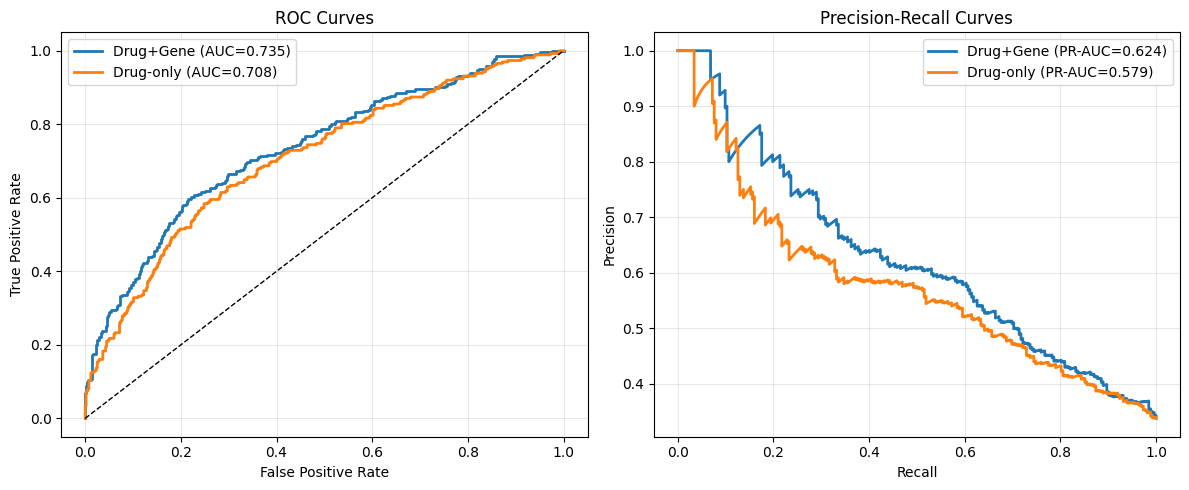

✅ نمودارهای ROC و PR ذخیره شدند: roc_pr_comparison.png

📋 خلاصه نهایی برای مقاله:
بهترین فراپارامترها: alpha=0.3, lr=5e-05, word_dropout=0.3
مدل کامل (Drug+Gene) - Test AUC: 0.7350, F1: 0.5869
مدل پایه (Drug-only) - Test AUC: 0.7084, F1: 0.5680
ΔAUC = 0.0266 (p=0.0501)


In [1]:
# ============================================================
# ✅ کد جامع برای مقایسه مدل کامل (Drug+Gene) و مدل پایه (Drug-only)
# ------------------------------------------------------------
# شامل:
#   - بارگذاری و پیش‌پردازش داده
#   - تعریف هر دو مدل
#   - اعتبارسنجی ۵‑فولد با ذخیره معیارهای هر فولد
#   - محاسبه میانگین، انحراف معیار و p‑value
#   - ارزیابی نهایی روی تست با ensemble و تعیین آستانه بهینه
#   - رسم نمودارهای ROC و Precision‑Recall
# ============================================================

import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix, f1_score, roc_auc_score
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from scipy.stats import ttest_rel
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from rdkit import Chem, RDLogger
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import time
import warnings
warnings.filterwarnings('ignore')

RDLogger.DisableLog("rdApp.*")

# ----------------------------------------------
# 1) تنظیمات پایه (مشترک)
# ----------------------------------------------
ROOT = Path.cwd()
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
NUM_EPOCHS_FINAL = 100
PATIENCE_FINAL = 5
FP_RADIUS = 2
FP_NBITS = 1024
GENE_LEN = 300
gene_cols = [
    "cell_sentence",
    "c2s_treated_d1_sentence",
    "c2s_treated_d2_sentence",
    "c2s_treated_d12_direct",
]
RANK_WEIGHT_MODE = "inv"
RANK_LEARNABLE_WEIGHTS = True
GENE_D_MODEL = 256
D_SHARED = 256
FUSION_HEADS = 4
FUSION_LAYERS = 2
FUSION_DROPOUT = 0.30
NUM_WORKERS = 0
USE_CELL_EMB = False
MONITOR = "auc"
NULLISH = {"", "none", "nan", "null", "na", "n/a", "undefined", "missing"}

# بهترین فراپارامترهای به‌دست‌آمده از جستجو (از خروجی قبلی)
BEST_ALPHA = 0.3
BEST_LR = 5e-5
BEST_DROPOUT = 0.3

# ----------------------------------------------
# 2) توابع کمکی پایه (همانند قبل)
# ----------------------------------------------
def _make_rank_weights(max_len, mode="inv", alpha=0.3, beta=0.03):
    i = torch.arange(max_len, dtype=torch.float32)
    if mode == "linear":
        w = (max_len - i) / max_len
    elif mode == "inv":
        w = 1.0 / (1.0 + i) ** alpha
    else:
        w = torch.exp(-beta * i)
    w = w / (w.sum() + 1e-12)
    return w

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def clean_text(x):
    if x is None:
        return ""
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return ""
    return s

def clean_smiles_string(x):
    if x is None:
        return None
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return None
    return s

def split_genes(text: str):
    if isinstance(text, str):
        t = text.strip()
        return t.split() if t else []
    return []

def pad_list(ids, target_len, pad_id=0):
    if len(ids) >= target_len:
        return ids[:target_len]
    return ids + [pad_id] * (target_len - len(ids))

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(FP_NBITS, dtype=np.float32)
    gen = GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
    fp = gen.GetFingerprint(mol)
    return np.array(fp, dtype=np.float32)

def standardize_smiles_rdkit(s):
    s = clean_smiles_string(s)
    if not s:
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    try:
        from rdkit.Chem.MolStandardize import rdMolStandardize
        lfc = rdMolStandardize.LargestFragmentChooser()
        mol = lfc.choose(mol)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

def threshold_sweep_0_to_100(y_true, y_prob):
    best_f1 = -1.0
    best_thr = 0.5
    for t_int in range(101):
        thr = t_int / 100.0
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

def metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
    }

# ----------------------------------------------
# 3) بارگذاری داده (مشترک)
# ----------------------------------------------
custom_path = Path(r"C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv")
candidates = [custom_path, ROOT / "df_with_c2s.csv.gz", ROOT / "c2s27b_out_0_4396_in300_out300 (2).csv"]
df_path = next((p for p in candidates if p.exists()), None)
if df_path is None:
    raise FileNotFoundError(f"فایل داده پیدا نشد: {custom_path}")
is_gz = str(df_path).endswith(".gz")
print("Using data file:", df_path)

hdr = pd.read_csv(df_path, compression="gzip" if is_gz else None, nrows=0)
cols = hdr.columns.tolist()

cell_col = "cell" if "cell" in cols else None
d1_col = "drug1_smiles" if "drug1_smiles" in cols else None
d2_col = "drug2_smiles" if "drug2_smiles" in cols else None
label_has = "label" in cols or "classification" in cols
missing_gene = [c for c in gene_cols if c not in cols]

if cell_col is None or d1_col is None or d2_col is None:
    raise ValueError("ستون‌های 'cell'، 'drug1_smiles' یا 'drug2_smiles' وجود ندارند.")
if missing_gene:
    raise ValueError(f"ستون‌های ژنی زیر یافت نشدند: {missing_gene}")
if not label_has:
    raise ValueError("ستون 'label' یا 'classification' وجود ندارد.")

usecols = [cell_col, d1_col, d2_col] + gene_cols
if "label" in cols:
    usecols.append("label")
if "classification" in cols:
    usecols.append("classification")

df = pd.read_csv(df_path, compression="gzip" if is_gz else None, usecols=usecols)

rename_map = {}
if cell_col != "cell":
    rename_map[cell_col] = "cell"
if d1_col != "drug1_smiles":
    rename_map[d1_col] = "drug1_smiles"
if d2_col != "drug2_smiles":
    rename_map[d2_col] = "drug2_smiles"
df = df.rename(columns=rename_map)

def make_binary_label(df_):
    out = pd.Series([np.nan] * len(df_), index=df_.index, dtype="float")
    if "label" in df_.columns:
        s_raw = df_["label"]
        s_str = s_raw.astype(str).str.strip().str.lower()
        num = pd.to_numeric(s_raw, errors="coerce")
        mapped = s_str.map({"synergy":1, "antagonism":0, "1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
        out = num.fillna(mapped)
    if out.isna().any() and "classification" in df_.columns:
        c = df_["classification"].astype(str).str.strip().str.lower()
        mapped = c.map({"synergy":1, "antagonism":0, "1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
        out = out.fillna(mapped)
    return out

df["label"] = make_binary_label(df)
need_cols = ["cell", "drug1_smiles", "drug2_smiles", "label"] + gene_cols
df = df[need_cols].copy()

for c in gene_cols:
    df[c] = df[c].apply(clean_text)

df = df.dropna(subset=["label"]).reset_index(drop=True)
df["label"] = df["label"].astype(float).round().astype(int).clip(0,1)
df["cell"] = df["cell"].astype(str)

print("Shape raw:", df.shape, "| Unique cells:", df["cell"].nunique(), "| label:", df["label"].value_counts().to_dict())

def apply_smiles_standardization(df_):
    std1, std2 = [], []
    invalid = 0
    for a,b in zip(df_["drug1_smiles"], df_["drug2_smiles"]):
        a0 = clean_smiles_string(a)
        b0 = clean_smiles_string(b)
        sa = standardize_smiles_rdkit(a0) if a0 else None
        sb = standardize_smiles_rdkit(b0) if b0 else None
        if sa is None or sb is None:
            invalid += 1
            std1.append("")
            std2.append("")
        else:
            std1.append(sa)
            std2.append(sb)
    df_ = df_.copy()
    df_["drug1_smiles_std"] = std1
    df_["drug2_smiles_std"] = std2
    df_ok = df_[(df_["drug1_smiles_std"]!="") & (df_["drug2_smiles_std"]!="")].copy()
    df_ok["drug1_smiles"] = df_ok["drug1_smiles_std"]
    df_ok["drug2_smiles"] = df_ok["drug2_smiles_std"]
    df_ok = df_ok.drop(columns=["drug1_smiles_std","drug2_smiles_std"])
    print(f"SMILES standardization: dropped {invalid} invalid rows")
    return df_ok.reset_index(drop=True)

df = apply_smiles_standardization(df)
print("After standardize:", df.shape)

print("Computing Morgan fingerprints...")
df["fp1"] = df["drug1_smiles"].apply(smiles_to_fingerprint)
df["fp2"] = df["drug2_smiles"].apply(smiles_to_fingerprint)
print("Done.")

df["drug_pair"] = df.apply(
    lambda row: "||".join(sorted([row["drug1_smiles"], row["drug2_smiles"]])),
    axis=1
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss.split(df, df["label"], groups=df["drug_pair"]))
df_cv = df.iloc[trainval_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)
print(f"CV rows: {len(df_cv)}, Test rows: {len(df_test)}")
print(f"CV unique drug pairs: {df_cv['drug_pair'].nunique()}, Test unique drug pairs: {df_test['drug_pair'].nunique()}")

# ----------------------------------------------
# 4) تعریف Dataset‌ها و مدل‌ها
# ----------------------------------------------
# 4‑الف) Dataset برای مدل کامل (با ژن)
class SynergyDataset(Dataset):
    def __init__(self, df_, training, encode_cell_fn, encode_genes_fn,
                 gene_unk_id, gene_pad_id, gene_word_dropout_p=0.0):
        self.df = df_.reset_index(drop=True)
        self.training = training
        self.encode_cell = encode_cell_fn
        self.encode_genes = encode_genes_fn
        self.GENE_UNK = gene_unk_id
        self.GENE_PAD = gene_pad_id
        self.gene_word_dropout_p = gene_word_dropout_p
        self.gene_cache = {}
        self.fp1_list = df_["fp1"].values
        self.fp2_list = df_["fp2"].values

    def __len__(self):
        return len(self.df)

    def _get_gene(self, sentence):
        sentence = "" if not isinstance(sentence, str) else sentence
        t = self.gene_cache.get(sentence)
        if t is None:
            t = self.encode_genes(sentence)
            self.gene_cache[sentence] = t
        return t.clone()

    def _token_dropout(self, ids, drop_p, unk_id, pad_id):
        if not self.training or drop_p <= 0:
            return ids
        out = ids.clone()
        mask = (torch.rand_like(out.float()) < drop_p) & out.ne(pad_id)
        out[mask] = unk_id
        return out

    def __getitem__(self, i):
        r = self.df.iloc[i]
        cell_id = self.encode_cell(r["cell"])
        g_base = self._get_gene(r["cell_sentence"])
        g_d1 = self._get_gene(r["c2s_treated_d1_sentence"])
        g_d2 = self._get_gene(r["c2s_treated_d2_sentence"])
        g_d12 = self._get_gene(r["c2s_treated_d12_direct"])
        g_base = self._token_dropout(g_base, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d1 = self._token_dropout(g_d1, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d2 = self._token_dropout(g_d2, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d12 = self._token_dropout(g_d12, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        fp1 = torch.tensor(self.fp1_list[i], dtype=torch.float32)
        fp2 = torch.tensor(self.fp2_list[i], dtype=torch.float32)
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y

# 4‑ب) Dataset برای مدل پایه (فقط دارو)
class DrugDataset(Dataset):
    def __init__(self, df_):
        self.fp1 = df_["fp1"].values
        self.fp2 = df_["fp2"].values
        self.y = df_["label"].values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (torch.tensor(self.fp1[i], dtype=torch.float32),
                torch.tensor(self.fp2[i], dtype=torch.float32),
                torch.tensor(float(self.y[i]), dtype=torch.float32))

# 4‑ج) مدل کامل (Drug+Gene)
class RankWeightedGeneEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, pad_idx, dropout, max_len, weight_mode,
                 alpha=0.3, beta=0.03, learnable=False):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.max_len = max_len
        w = _make_rank_weights(max_len, weight_mode, alpha, beta)
        if learnable:
            self.rank_w = nn.Parameter(w)
        else:
            self.register_buffer("rank_w", w)
        self.weight_mode = weight_mode
        self.alpha = alpha
        self.beta = beta

    def forward(self, ids):
        B, L = ids.shape
        if L != self.max_len:
            w = _make_rank_weights(L, self.weight_mode, self.alpha, self.beta).to(ids.device)
        else:
            w = self.rank_w[:L].to(ids.device)
        pad_mask = ids.eq(self.pad_idx)
        h = self.emb(ids)
        h = self.drop(h)
        ww = w.view(1, L, 1) * (~pad_mask).unsqueeze(-1).float()
        num = (h * ww).sum(dim=1)
        den = ww.sum(dim=1).clamp(min=1e-8)
        out = num / den
        return self.norm(out)

class LightFusionTransformer(nn.Module):
    def __init__(self, d_shared, n_tokens, n_heads, n_layers, dropout):
        super().__init__()
        self.fuse_token = nn.Parameter(torch.zeros(1,1,d_shared))
        self.pos_emb = nn.Parameter(torch.zeros(1,1+n_tokens,d_shared))
        layer = nn.TransformerEncoderLayer(d_model=d_shared, nhead=n_heads, dim_feedforward=4*d_shared,
                                           dropout=dropout, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_shared)
        nn.init.normal_(self.fuse_token, std=0.02)
        nn.init.normal_(self.pos_emb, std=0.02)

    def forward(self, tokens):
        B = tokens.size(0)
        fuse = self.fuse_token.expand(B, -1, -1)
        x = torch.cat([fuse, tokens], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]
        h = self.enc(x)
        h = self.norm(h)
        return h[:,0,:]

class SynergyModelTwoDimGate(nn.Module):
    def __init__(self, vocab_cells, vocab_genes, gene_pad_id, use_cell_emb=False,
                 d_gene=GENE_D_MODEL, d_shared=D_SHARED, alpha=0.3, gene_word_dropout_p=0.3):
        super().__init__()
        self.use_cell_emb = use_cell_emb
        self.d_shared = d_shared
        self.gene_word_dropout_p = gene_word_dropout_p

        if use_cell_emb:
            self.cell_emb = nn.Embedding(vocab_cells, 64)
            cell_dim = 64
        else:
            self.cell_emb = None
            cell_dim = 0

        self.gene_encoder = RankWeightedGeneEncoder(
            vocab_size=vocab_genes, d_model=d_gene, pad_idx=gene_pad_id,
            dropout=0.20, max_len=GENE_LEN, weight_mode=RANK_WEIGHT_MODE,
            alpha=alpha, learnable=RANK_LEARNABLE_WEIGHTS
        )
        self.proj_gene = nn.Linear(d_gene, d_shared, bias=False)
        self.proj_smiles = nn.Linear(FP_NBITS, d_shared, bias=False)
        self.norm = nn.LayerNorm(d_shared)

        self.num_gene_tokens = 5
        self.num_smiles_tokens = 3
        self.num_tokens = self.num_gene_tokens + self.num_smiles_tokens

        context_dim = d_shared + cell_dim
        self.gate_net = nn.Sequential(
            nn.Linear(context_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 2),
            nn.Sigmoid()
        )

        self.fusion = LightFusionTransformer(
            d_shared=d_shared, n_tokens=self.num_tokens,
            n_heads=FUSION_HEADS, n_layers=FUSION_LAYERS,
            dropout=FUSION_DROPOUT
        )

        in_dim = (cell_dim if use_cell_emb else 0) + d_shared
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256), nn.GELU(), nn.Dropout(0.40),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(128, 1)
        )

    def forward(self, cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2):
        if self.use_cell_emb:
            h_cell = self.cell_emb(cell_id)
        else:
            h_cell = None

        h_base = self.gene_encoder(g_base)
        h_d1   = self.gene_encoder(g_d1)
        h_d2   = self.gene_encoder(g_d2)
        h_d12  = self.gene_encoder(g_d12)

        z_base = self.norm(self.proj_gene(h_base))
        z_d1   = self.norm(self.proj_gene(h_d1))
        z_d2   = self.norm(self.proj_gene(h_d2))
        z_d12  = self.norm(self.proj_gene(h_d12))

        e12   = self.norm(z_d12 - z_base)
        e_sum = self.norm(z_d1 + z_d2 - 2*z_base)
        e_abs = self.norm(torch.abs(z_d1 - z_d2))
        e_mul = self.norm(z_d1 * z_d2)

        gene_tokens = torch.stack([z_base, e12, e_sum, e_abs, e_mul], dim=1)

        z_sm1 = self.norm(self.proj_smiles(fp1))
        z_sm2 = self.norm(self.proj_smiles(fp2))
        sm_sum = self.norm(z_sm1 + z_sm2)
        sm_abs = self.norm(torch.abs(z_sm1 - z_sm2))
        sm_mul = self.norm(z_sm1 * z_sm2)
        smiles_tokens = torch.stack([sm_sum, sm_abs, sm_mul], dim=1)

        all_tokens = torch.cat([gene_tokens, smiles_tokens], dim=1)
        token_mean = all_tokens.mean(dim=1)

        if self.use_cell_emb:
            context = torch.cat([token_mean, h_cell], dim=-1)
        else:
            context = token_mean

        gate_out = self.gate_net(context)
        w_gene = gate_out[:, 0:1]
        w_drug = gate_out[:, 1:2]

        weighted_gene_tokens = gene_tokens * w_gene.unsqueeze(-1)
        weighted_smiles_tokens = smiles_tokens * w_drug.unsqueeze(-1)

        weighted_all = torch.cat([weighted_gene_tokens, weighted_smiles_tokens], dim=1)
        fused = self.fusion(weighted_all)

        if self.use_cell_emb:
            combined = torch.cat([h_cell, fused], dim=-1)
        else:
            combined = fused
        logits = self.mlp(combined).squeeze(-1)
        return logits

# 4‑د) مدل پایه (Drug-only)
class DrugOnlyModel(nn.Module):
    def __init__(self, d_shared=D_SHARED):
        super().__init__()
        self.proj = nn.Linear(FP_NBITS, d_shared, bias=False)
        self.norm = nn.LayerNorm(d_shared)
        self.num_tokens = 5
        self.fusion = LightFusionTransformer(d_shared, self.num_tokens, FUSION_HEADS, FUSION_LAYERS, FUSION_DROPOUT)
        self.mlp = nn.Sequential(
            nn.Linear(d_shared, 256), nn.GELU(), nn.Dropout(0.40),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(128, 1))

    def forward(self, fp1, fp2):
        z1 = self.norm(self.proj(fp1))
        z2 = self.norm(self.proj(fp2))
        tokens = torch.stack([z1, z2, self.norm(z1 + z2),
                              self.norm(torch.abs(z1 - z2)), self.norm(z1 * z2)], dim=1)
        return self.mlp(self.fusion(tokens)).squeeze(-1)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ----------------------------------------------
# 5) توابع آموزش و ارزیابی (مشترک)
# ----------------------------------------------
def batch_to_device_full(batch, device):
    cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch
    return (cell_id.to(device), g_base.to(device), g_d1.to(device), g_d2.to(device), g_d12.to(device),
            fp1.to(device), fp2.to(device), y.to(device))

def batch_to_device_drug(batch, device):
    fp1, fp2, y = batch
    return fp1.to(device), fp2.to(device), y.to(device)

@torch.no_grad()
def eval_collect_full(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    ys, ps = [], []
    for batch in loader:
        cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, device)
        logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
        loss = criterion(logits, y)
        prob = torch.sigmoid(logits)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
        ys.append(y.cpu().numpy())
        ps.append(prob.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return total_loss / total_n, y_true, y_prob

@torch.no_grad()
def eval_collect_drug(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    ys, ps = [], []
    for batch in loader:
        fp1, fp2, y = batch_to_device_drug(batch, device)
        logits = model(fp1, fp2)
        loss = criterion(logits, y)
        prob = torch.sigmoid(logits)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
        ys.append(y.cpu().numpy())
        ps.append(prob.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return total_loss / total_n, y_true, y_prob

def train_one_epoch_full(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for batch in loader:
        cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, device)
        optimizer.zero_grad()
        logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (pred == y).sum().item()
        total_n += y.size(0)
    return total_loss / total_n, total_correct / total_n

def train_one_epoch_drug(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for batch in loader:
        fp1, fp2, y = batch_to_device_drug(batch, device)
        optimizer.zero_grad()
        logits = model(fp1, fp2)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (pred == y).sum().item()
        total_n += y.size(0)
    return total_loss / total_n, total_correct / total_n

def train_with_early_stopping_full(model, train_loader, val_loader, criterion, optimizer,
                                   epochs, patience, monitor=MONITOR, verbose=False):
    if monitor == "auc":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        best_metric = -1.0
        better = lambda cur, best: cur > best + 1e-5
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        best_metric = float("inf")
        better = lambda cur, best: cur < best - 1e-6

    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch_full(model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP)
        val_loss, y_true, y_prob = eval_collect_full(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob)
        cur_metric = val_auc if monitor == "auc" else val_loss
        scheduler.step(cur_metric)

        if verbose:
            m05 = metrics_at_threshold(y_true, y_prob, threshold=0.5)
            print(f"Epoch {epoch:3d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} | F1@0.5 {m05['f1']:.4f} | Val AUC {val_auc:.4f}")

        if better(cur_metric, best_metric):
            best_metric = cur_metric
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, best_state

def train_with_early_stopping_drug(model, train_loader, val_loader, criterion, optimizer,
                                   epochs, patience, monitor=MONITOR, verbose=False):
    if monitor == "auc":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        best_metric = -1.0
        better = lambda cur, best: cur > best + 1e-5
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        best_metric = float("inf")
        better = lambda cur, best: cur < best - 1e-6

    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch_drug(model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP)
        val_loss, y_true, y_prob = eval_collect_drug(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob)
        cur_metric = val_auc if monitor == "auc" else val_loss
        scheduler.step(cur_metric)

        if verbose:
            m05 = metrics_at_threshold(y_true, y_prob, threshold=0.5)
            print(f"Epoch {epoch:3d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} | F1@0.5 {m05['f1']:.4f} | Val AUC {val_auc:.4f}")

        if better(cur_metric, best_metric):
            best_metric = cur_metric
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, best_state

# ----------------------------------------------
# 6) توابع کمکی برای ساخت واکبلری و انکودر (برای مدل کامل)
# ----------------------------------------------
def build_vocabs_from_train(df_train):
    cell2id = {"<UNK_CELL>":0}
    for c in sorted(df_train["cell"].unique()):
        if c not in cell2id:
            cell2id[c] = len(cell2id)
    gene_vocab = set()
    for col in gene_cols:
        for txt in df_train[col].dropna().astype(str).unique():
            gene_vocab.update(split_genes(txt))
    gene2id = {"<PAD>":0, "<UNK>":1}
    for g in sorted(gene_vocab):
        if g not in gene2id:
            gene2id[g] = len(gene2id)
    return cell2id, gene2id

def encode_cell_factory(cell2id):
    UNK_CELL = cell2id["<UNK_CELL>"]
    def encode_cell(cell_name):
        return torch.tensor(cell2id.get(str(cell_name), UNK_CELL), dtype=torch.long)
    return encode_cell, UNK_CELL

def encode_genes_factory(gene2id, pad_to_len):
    GENE_PAD = gene2id["<PAD>"]
    GENE_UNK = gene2id["<UNK>"]
    def encode_genes(sentence):
        sentence = "" if not isinstance(sentence, str) else sentence
        genes = split_genes(sentence)[:pad_to_len]
        ids = [gene2id.get(g, GENE_UNK) for g in genes]
        ids = pad_list(ids, pad_to_len, pad_id=GENE_PAD)
        return torch.tensor(ids, dtype=torch.long)
    return encode_genes, GENE_PAD, GENE_UNK

# ----------------------------------------------
# 7) ارزیابی ۵‑فولد برای هر مدل و ذخیره معیارها
# ----------------------------------------------
def evaluate_model_on_cv(model_type, df_cv, test_set=False):
    """
    model_type: 'full' یا 'drug'
    بازگرداندن دیکشنری شامل:
        - fold_metrics: لیستی از دیکشنری‌های معیار برای هر فولد (روی validation)
        - best_thr: آستانه بهینه از روی validation کل
        - test_metrics: دیکشنری معیارهای نهایی روی تست (ensemble)
        - fold_states: لیستی از stateهای هر فولد
    """
    seed_everything(SEED)
    gkf = GroupKFold(n_splits=5)
    fold_metrics = []   # هر عضو: dict شامل auc, f1, acc, pr_auc, bal_acc
    fold_states = []
    all_val_probs = []
    all_val_true = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df_cv, df_cv["label"], groups=df_cv["drug_pair"]), 1):
        print(f"\n{'='*50}\n{model_type.upper()} - FOLD {fold}/5")
        df_train = df_cv.iloc[train_idx].reset_index(drop=True)
        df_val = df_cv.iloc[val_idx].reset_index(drop=True)

        if model_type == 'full':
            # ساخت واکبلری و انکودر
            cell2id, gene2id = build_vocabs_from_train(df_train)
            encode_cell, UNK_CELL = encode_cell_factory(cell2id)
            encode_genes, GENE_PAD, GENE_UNK = encode_genes_factory(gene2id, GENE_LEN)

            train_ds = SynergyDataset(df_train, training=True, encode_cell_fn=encode_cell,
                                      encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                      gene_pad_id=GENE_PAD, gene_word_dropout_p=BEST_DROPOUT)
            val_ds = SynergyDataset(df_val, training=False, encode_cell_fn=encode_cell,
                                    encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                    gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)

            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            pos = (df_train["label"] == 1).sum()
            neg = len(df_train) - pos
            pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32, device=DEVICE)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                           gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                           d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                           alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WEIGHT_DECAY)

            model, best_state = train_with_early_stopping_full(
                model, train_loader, val_loader, criterion, optimizer,
                epochs=NUM_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=True
            )

            val_loss, y_true, y_prob = eval_collect_full(model, val_loader, criterion, DEVICE)

            # ذخیره state و اطلاعات مورد نیاز برای تست
            fold_states.append({
                "state": best_state,
                "cell2id": cell2id,
                "gene2id": gene2id,
                "GENE_PAD": GENE_PAD,
                "UNK_CELL": UNK_CELL,
                "GENE_UNK": GENE_UNK,
            })

        else:  # drug-only
            train_ds = DrugDataset(df_train)
            val_ds = DrugDataset(df_val)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            pos = (df_train["label"] == 1).sum()
            neg = len(df_train) - pos
            pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32, device=DEVICE)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            model = DrugOnlyModel().to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WEIGHT_DECAY)

            model, best_state = train_with_early_stopping_drug(
                model, train_loader, val_loader, criterion, optimizer,
                epochs=NUM_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=True
            )

            val_loss, y_true, y_prob = eval_collect_drug(model, val_loader, criterion, DEVICE)

            fold_states.append({"state": best_state})

        # محاسبه معیارهای این فولد روی validation
        auc = roc_auc_score(y_true, y_prob)
        # برای F1 از آستانه بهینه در همین فولد استفاده می‌کنیم (برای مقایسه)
        best_thr_fold, _ = threshold_sweep_0_to_100(y_true, y_prob)
        y_pred_fold = (y_prob >= best_thr_fold).astype(int)
        f1 = f1_score(y_true, y_pred_fold)
        acc = accuracy_score(y_true, y_pred_fold)
        pr_auc = average_precision_score(y_true, y_prob)
        bal_acc = balanced_accuracy_score(y_true, y_pred_fold)

        fold_metrics.append({
            "auc": auc,
            "f1": f1,
            "acc": acc,
            "pr_auc": pr_auc,
            "bal_acc": bal_acc
        })
        all_val_true.append(y_true)
        all_val_probs.append(y_prob)

        print(f"  Val AUC={auc:.4f}, F1={f1:.4f}, Acc={acc:.4f}, PR-AUC={pr_auc:.4f}, BalAcc={bal_acc:.4f}")

    # محاسبه آستانه بهینه روی کل validation (برای تست)
    all_val_true_concat = np.concatenate(all_val_true)
    all_val_probs_concat = np.concatenate(all_val_probs)
    best_thr, _ = threshold_sweep_0_to_100(all_val_true_concat, all_val_probs_concat)
    print(f"\nBest threshold (on all validation): {best_thr:.3f}")

    # ارزیابی روی تست با ensemble
    test_probs = np.zeros(len(df_test))
    for idx, fm in enumerate(fold_states):
        if model_type == 'full':
            cell2id = fm["cell2id"]
            gene2id = fm["gene2id"]
            GENE_PAD = fm["GENE_PAD"]
            GENE_UNK = fm["GENE_UNK"]
            encode_cell, _ = encode_cell_factory(cell2id)
            encode_genes, _, _ = encode_genes_factory(gene2id, GENE_LEN)

            test_ds = SynergyDataset(df_test, training=False, encode_cell_fn=encode_cell,
                                     encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                     gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                           gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                           d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                           alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
            model.load_state_dict(fm["state"])
            model.eval()
            probs = []
            with torch.no_grad():
                for batch in test_loader:
                    cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, DEVICE)
                    logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
                    probs.extend(torch.sigmoid(logits).cpu().numpy())
            test_probs += np.array(probs) / len(fold_states)
        else:
            test_ds = DrugDataset(df_test)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model = DrugOnlyModel().to(DEVICE)
            model.load_state_dict(fm["state"])
            model.eval()
            probs = []
            with torch.no_grad():
                for fp1, fp2, y in test_loader:
                    fp1, fp2 = fp1.to(DEVICE), fp2.to(DEVICE)
                    probs.extend(torch.sigmoid(model(fp1, fp2)).cpu().numpy())
            test_probs += np.array(probs) / len(fold_states)

    test_true = df_test["label"].values
    y_pred_test = (test_probs >= best_thr).astype(int)
    test_metrics = {
        "accuracy": accuracy_score(test_true, y_pred_test),
        "auc": roc_auc_score(test_true, test_probs),
        "f1": f1_score(test_true, y_pred_test),
        "pr_auc": average_precision_score(test_true, test_probs),
        "bal_acc": balanced_accuracy_score(test_true, y_pred_test),
        "threshold": best_thr,
        "confusion_matrix": confusion_matrix(test_true, y_pred_test),
        "classification_report": classification_report(test_true, y_pred_test, target_names=['antagonism', 'synergy'])
    }

    return {
        "fold_metrics": fold_metrics,
        "best_thr": best_thr,
        "test_metrics": test_metrics,
        "fold_states": fold_states,
        "all_val_probs": all_val_probs_concat,
        "all_val_true": all_val_true_concat
    }

# ----------------------------------------------
# 8) اجرای ارزیابی برای هر دو مدل
# ----------------------------------------------
print("\n" + "="*80)
print("🚀 شروع ارزیابی ۵‑فولد برای مدل کامل (Drug+Gene)")
print("="*80)
results_full = evaluate_model_on_cv('full', df_cv)

print("\n" + "="*80)
print("🚀 شروع ارزیابی ۵‑فولد برای مدل پایه (Drug-only)")
print("="*80)
results_drug = evaluate_model_on_cv('drug', df_cv)

# ----------------------------------------------
# 9) استخراج معیارهای هر فولد برای محاسبه انحراف معیار و p-value
# ----------------------------------------------
fold_auc_full = [m['auc'] for m in results_full['fold_metrics']]
fold_f1_full = [m['f1'] for m in results_full['fold_metrics']]
fold_acc_full = [m['acc'] for m in results_full['fold_metrics']]
fold_pr_full = [m['pr_auc'] for m in results_full['fold_metrics']]
fold_bal_full = [m['bal_acc'] for m in results_full['fold_metrics']]

fold_auc_drug = [m['auc'] for m in results_drug['fold_metrics']]
fold_f1_drug = [m['f1'] for m in results_drug['fold_metrics']]
fold_acc_drug = [m['acc'] for m in results_drug['fold_metrics']]
fold_pr_drug = [m['pr_auc'] for m in results_drug['fold_metrics']]
fold_bal_drug = [m['bal_acc'] for m in results_drug['fold_metrics']]

# محاسبه میانگین و انحراف معیار
def mean_std(values):
    return np.mean(values), np.std(values)

auc_full_mean, auc_full_std = mean_std(fold_auc_full)
f1_full_mean, f1_full_std = mean_std(fold_f1_full)
acc_full_mean, acc_full_std = mean_std(fold_acc_full)
pr_full_mean, pr_full_std = mean_std(fold_pr_full)
bal_full_mean, bal_full_std = mean_std(fold_bal_full)

auc_drug_mean, auc_drug_std = mean_std(fold_auc_drug)
f1_drug_mean, f1_drug_std = mean_std(fold_f1_drug)
acc_drug_mean, acc_drug_std = mean_std(fold_acc_drug)
pr_drug_mean, pr_drug_std = mean_std(fold_pr_drug)
bal_drug_mean, bal_drug_std = mean_std(fold_bal_drug)

# محاسبه p-value با آزمون t زوجی (مقایسه فولدهای متناظر)
p_auc = ttest_rel(fold_auc_full, fold_auc_drug).pvalue
p_f1 = ttest_rel(fold_f1_full, fold_f1_drug).pvalue
p_acc = ttest_rel(fold_acc_full, fold_acc_drug).pvalue
p_pr = ttest_rel(fold_pr_full, fold_pr_drug).pvalue
p_bal = ttest_rel(fold_bal_full, fold_bal_drug).pvalue

# ----------------------------------------------
# 10) چاپ جدول نهایی با انحراف معیار و p-value
# ----------------------------------------------
print("\n" + "="*80)
print("📊 جدول مقایسه مدل‌ها (میانگین ± انحراف معیار روی ۵ فولد)")
print("="*80)
print(f"{'مدل':<15} {'Accuracy':<20} {'AUC':<20} {'F1':<20} {'PR-AUC':<20} {'Bal Acc':<20}")
print("-"*115)
print(f"{'Drug-only':<15} {acc_drug_mean:.4f}±{acc_drug_std:.4f}   {auc_drug_mean:.4f}±{auc_drug_std:.4f}   {f1_drug_mean:.4f}±{f1_drug_std:.4f}   {pr_drug_mean:.4f}±{pr_drug_std:.4f}   {bal_drug_mean:.4f}±{bal_drug_std:.4f}")
print(f"{'Drug+Gene':<15} {acc_full_mean:.4f}±{acc_full_std:.4f}   {auc_full_mean:.4f}±{auc_full_std:.4f}   {f1_full_mean:.4f}±{f1_full_std:.4f}   {pr_full_mean:.4f}±{pr_full_std:.4f}   {bal_full_mean:.4f}±{bal_full_std:.4f}")
print("-"*115)
print(f"{'p-value':<15} {p_acc:.4f}       {p_auc:.4f}       {p_f1:.4f}       {p_pr:.4f}       {p_bal:.4f}")
print("="*80)

# ----------------------------------------------
# 11) نتایج نهایی روی تست
# ----------------------------------------------
print("\n" + "="*80)
print("📊 نتایج نهایی روی تست (ensemble با آستانه بهینه)")
print("="*80)
for model_name, res in [("Drug-only", results_drug), ("Drug+Gene", results_full)]:
    tm = res['test_metrics']
    print(f"\n{model_name}:")
    print(f"  Accuracy: {tm['accuracy']:.4f}")
    print(f"  AUC: {tm['auc']:.4f}")
    print(f"  F1: {tm['f1']:.4f}")
    print(f"  PR-AUC: {tm['pr_auc']:.4f}")
    print(f"  Balanced Acc: {tm['bal_acc']:.4f}")
    print(f"  Threshold: {tm['threshold']:.3f}")
    print("  Classification Report:")
    print(tm['classification_report'])
    print("  Confusion Matrix:")
    print(tm['confusion_matrix'])

# ----------------------------------------------
# 12) رسم نمودارهای ROC و PR برای مدل کامل (روی تست)
# ----------------------------------------------
from sklearn.metrics import roc_curve, precision_recall_curve

test_true = df_test["label"].values
# برای مدل کامل
test_probs_full = np.zeros(len(df_test))
# دوباره ensemble بگیریم (می‌توان از results_full استفاده کرد ولی دوباره محاسبه می‌کنیم)
for fm in results_full['fold_states']:
    cell2id = fm["cell2id"]
    gene2id = fm["gene2id"]
    GENE_PAD = fm["GENE_PAD"]
    GENE_UNK = fm["GENE_UNK"]
    encode_cell, _ = encode_cell_factory(cell2id)
    encode_genes, _, _ = encode_genes_factory(gene2id, GENE_LEN)
    test_ds = SynergyDataset(df_test, training=False, encode_cell_fn=encode_cell,
                             encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                             gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                   gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                   d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                   alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
    model.load_state_dict(fm["state"])
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, DEVICE)
            logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    test_probs_full += np.array(probs) / len(results_full['fold_states'])

# برای مدل پایه
test_probs_drug = np.zeros(len(df_test))
for fm in results_drug['fold_states']:
    test_ds = DrugDataset(df_test)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = DrugOnlyModel().to(DEVICE)
    model.load_state_dict(fm["state"])
    model.eval()
    probs = []
    with torch.no_grad():
        for fp1, fp2, y in test_loader:
            fp1, fp2 = fp1.to(DEVICE), fp2.to(DEVICE)
            probs.extend(torch.sigmoid(model(fp1, fp2)).cpu().numpy())
    test_probs_drug += np.array(probs) / len(results_drug['fold_states'])

# رسم ROC
fpr_full, tpr_full, _ = roc_curve(test_true, test_probs_full)
fpr_drug, tpr_drug, _ = roc_curve(test_true, test_probs_drug)
auc_full = roc_auc_score(test_true, test_probs_full)
auc_drug = roc_auc_score(test_true, test_probs_drug)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_full, tpr_full, label=f'Drug+Gene (AUC={auc_full:.3f})', lw=2)
plt.plot(fpr_drug, tpr_drug, label=f'Drug-only (AUC={auc_drug:.3f})', lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)

# رسم PR
prec_full, rec_full, _ = precision_recall_curve(test_true, test_probs_full)
prec_drug, rec_drug, _ = precision_recall_curve(test_true, test_probs_drug)
pr_auc_full = average_precision_score(test_true, test_probs_full)
pr_auc_drug = average_precision_score(test_true, test_probs_drug)

plt.subplot(1,2,2)
plt.plot(rec_full, prec_full, label=f'Drug+Gene (PR-AUC={pr_auc_full:.3f})', lw=2)
plt.plot(rec_drug, prec_drug, label=f'Drug-only (PR-AUC={pr_auc_drug:.3f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pr_comparison.png', dpi=300)
plt.show()
print("✅ نمودارهای ROC و PR ذخیره شدند: roc_pr_comparison.png")

# ----------------------------------------------
# 13) خلاصه نهایی برای مقاله
# ----------------------------------------------
print("\n" + "="*80)
print("📋 خلاصه نهایی برای مقاله:")
print("="*80)
print(f"بهترین فراپارامترها: alpha={BEST_ALPHA}, lr={BEST_LR:.0e}, word_dropout={BEST_DROPOUT}")
print(f"مدل کامل (Drug+Gene) - Test AUC: {results_full['test_metrics']['auc']:.4f}, F1: {results_full['test_metrics']['f1']:.4f}")
print(f"مدل پایه (Drug-only) - Test AUC: {results_drug['test_metrics']['auc']:.4f}, F1: {results_drug['test_metrics']['f1']:.4f}")
print(f"ΔAUC = {results_full['test_metrics']['auc'] - results_drug['test_metrics']['auc']:.4f} (p={p_auc:.4f})")
print("="*80)

Using data file: C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv
Shape raw: (4268, 8) | Unique cells: 52 | label: {0: 2929, 1: 1339}
SMILES standardization: dropped 383 invalid rows
After standardize: (3885, 8)
Computing Morgan fingerprints...
Done.
CV rows: 3047, Test rows: 838
CV unique cells: 41, Test unique cells: 11 (disjoint ✓)
CV unique drug pairs: 3017, Test unique drug pairs: 838
CV synergy rate: 0.343 | Test synergy rate: 0.234

🚀 شروع ارزیابی ۵‑فولد LEAVE-CELL-OUT برای مدل کامل (Drug+Gene)

FULL - FOLD 1/5  (train cells=33, val cells=8)
Epoch   1 | Train Loss 0.9031 Acc 0.4610 | Val Loss 0.8802 | F1@0.5 0.4076 | Val AUC 0.5231
Epoch   2 | Train Loss 0.8912 Acc 0.5502 | Val Loss 0.8765 | F1@0.5 0.3203 | Val AUC 0.5376
Epoch   3 | Train Loss 0.8685 Acc 0.6624 | Val Loss 0.8693 | F1@0.5 0.2655 | Val AUC 0.5611
Epoch   4 | Train Loss 0.8286 Acc 0.6970 | Val Loss 0.8669 | F1@0.5 0.2907 | Val AUC 0.5773
Epoch   5 | Train L

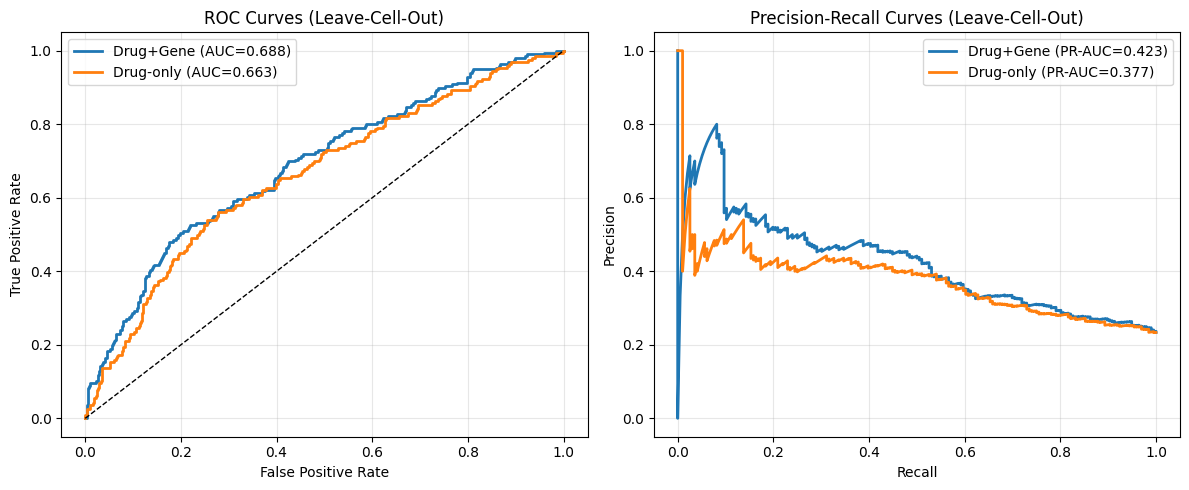

✅ نمودارهای ROC و PR ذخیره شدند: roc_pr_comparison_leave_cell_out.png

📋 خلاصه نهایی برای مقاله (LEAVE-CELL-OUT — آزمونِ تعمیمِ سلولی):
بهترین فراپارامترها: alpha=0.3, lr=5e-05, word_dropout=0.3
تقسیم: leave-cell-out (گروه = ردهٔ سلولی) | StratifiedGroupKFold = True
مدل کامل (Drug+Gene) - Test AUC: 0.6883, F1: 0.4662
مدل پایه (Drug-only) - Test AUC: 0.6626, F1: 0.4344
ΔAUC = 0.0256 (p=0.4172)


In [2]:
# ============================================================
# ✅ کد جامع برای مقایسه مدل کامل (Drug+Gene) و مدل پایه (Drug-only)
#     نسخهٔ LEAVE-CELL-OUT — برای جلوگیری از نشت اطلاعات از سلول
# ------------------------------------------------------------
# تفاوت با نسخهٔ قبل: گروه‌بندیِ تقسیم از "drug_pair" به "cell" تغییر کرده،
# یعنی هیچ ردهٔ سلولی هم در train و هم در val/test نیست (تعمیمِ سلولیِ واقعی).
# شامل:
#   - بارگذاری و پیش‌پردازش داده
#   - تعریف هر دو مدل
#   - اعتبارسنجی ۵‑فولد (StratifiedGroupKFold بر اساس سلول) با ذخیره معیارهای هر فولد
#   - محاسبه میانگین، انحراف معیار و p‑value
#   - ارزیابی نهایی روی تست با ensemble و تعیین آستانه بهینه
#   - رسم نمودارهای ROC و Precision‑Recall
#   - بررسی نشت: assertها تضمین می‌کنند هیچ سلولی بین train/val/test مشترک نباشد
# ============================================================

import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix, f1_score, roc_auc_score
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, StratifiedGroupKFold
from scipy.stats import ttest_rel
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from rdkit import Chem, RDLogger
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import time
import warnings
warnings.filterwarnings('ignore')

RDLogger.DisableLog("rdApp.*")

# ----------------------------------------------
# 1) تنظیمات پایه (مشترک)
# ----------------------------------------------
ROOT = Path.cwd()
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
NUM_EPOCHS_FINAL = 100
PATIENCE_FINAL = 5
FP_RADIUS = 2
FP_NBITS = 1024
GENE_LEN = 300
gene_cols = [
    "cell_sentence",
    "c2s_treated_d1_sentence",
    "c2s_treated_d2_sentence",
    "c2s_treated_d12_direct",
]
RANK_WEIGHT_MODE = "inv"
RANK_LEARNABLE_WEIGHTS = True
GENE_D_MODEL = 256
D_SHARED = 256
FUSION_HEADS = 4
FUSION_LAYERS = 2
FUSION_DROPOUT = 0.30
NUM_WORKERS = 0
USE_CELL_EMB = False          # ⚠️ تحتِ leave-cell-out حتماً False بماند (سلولِ دیده‌نشده امبدینگ ندارد)
MONITOR = "auc"
NULLISH = {"", "none", "nan", "null", "na", "n/a", "undefined", "missing"}

# ✅ گروه‌بندیِ تقسیم: "cell" برای leave-cell-out (قبلاً "drug_pair" بود)
SPLIT_GROUP = "cell"
# اگر می‌خواهی StratifiedGroupKFold را با GroupKFoldِ ساده جایگزین کنی، STRATIFY_CV=False کن
STRATIFY_CV = True

# بهترین فراپارامترهای به‌دست‌آمده از جستجو (از خروجی قبلی)
BEST_ALPHA = 0.3
BEST_LR = 5e-5
BEST_DROPOUT = 0.3

# ----------------------------------------------
# 2) توابع کمکی پایه (همانند قبل)
# ----------------------------------------------
def _make_rank_weights(max_len, mode="inv", alpha=0.3, beta=0.03):
    i = torch.arange(max_len, dtype=torch.float32)
    if mode == "linear":
        w = (max_len - i) / max_len
    elif mode == "inv":
        w = 1.0 / (1.0 + i) ** alpha
    else:
        w = torch.exp(-beta * i)
    w = w / (w.sum() + 1e-12)
    return w

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def clean_text(x):
    if x is None:
        return ""
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return ""
    return s

def clean_smiles_string(x):
    if x is None:
        return None
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return None
    return s

def split_genes(text: str):
    if isinstance(text, str):
        t = text.strip()
        return t.split() if t else []
    return []

def pad_list(ids, target_len, pad_id=0):
    if len(ids) >= target_len:
        return ids[:target_len]
    return ids + [pad_id] * (target_len - len(ids))

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(FP_NBITS, dtype=np.float32)
    gen = GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
    fp = gen.GetFingerprint(mol)
    return np.array(fp, dtype=np.float32)

def standardize_smiles_rdkit(s):
    s = clean_smiles_string(s)
    if not s:
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    try:
        from rdkit.Chem.MolStandardize import rdMolStandardize
        lfc = rdMolStandardize.LargestFragmentChooser()
        mol = lfc.choose(mol)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

def threshold_sweep_0_to_100(y_true, y_prob):
    best_f1 = -1.0
    best_thr = 0.5
    for t_int in range(101):
        thr = t_int / 100.0
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

def metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
    }

# ----------------------------------------------
# 3) بارگذاری داده (مشترک)
# ----------------------------------------------
custom_path = Path(r"C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv")
candidates = [custom_path, ROOT / "df_with_c2s.csv.gz", ROOT / "c2s27b_out_0_4396_in300_out300 (2).csv"]
df_path = next((p for p in candidates if p.exists()), None)
if df_path is None:
    raise FileNotFoundError(f"فایل داده پیدا نشد: {custom_path}")
is_gz = str(df_path).endswith(".gz")
print("Using data file:", df_path)

hdr = pd.read_csv(df_path, compression="gzip" if is_gz else None, nrows=0)
cols = hdr.columns.tolist()

cell_col = "cell" if "cell" in cols else None
d1_col = "drug1_smiles" if "drug1_smiles" in cols else None
d2_col = "drug2_smiles" if "drug2_smiles" in cols else None
label_has = "label" in cols or "classification" in cols
missing_gene = [c for c in gene_cols if c not in cols]

if cell_col is None or d1_col is None or d2_col is None:
    raise ValueError("ستون‌های 'cell'، 'drug1_smiles' یا 'drug2_smiles' وجود ندارند.")
if missing_gene:
    raise ValueError(f"ستون‌های ژنی زیر یافت نشدند: {missing_gene}")
if not label_has:
    raise ValueError("ستون 'label' یا 'classification' وجود ندارد.")

usecols = [cell_col, d1_col, d2_col] + gene_cols
if "label" in cols:
    usecols.append("label")
if "classification" in cols:
    usecols.append("classification")

df = pd.read_csv(df_path, compression="gzip" if is_gz else None, usecols=usecols)

rename_map = {}
if cell_col != "cell":
    rename_map[cell_col] = "cell"
if d1_col != "drug1_smiles":
    rename_map[d1_col] = "drug1_smiles"
if d2_col != "drug2_smiles":
    rename_map[d2_col] = "drug2_smiles"
df = df.rename(columns=rename_map)

def make_binary_label(df_):
    out = pd.Series([np.nan] * len(df_), index=df_.index, dtype="float")
    if "label" in df_.columns:
        s_raw = df_["label"]
        s_str = s_raw.astype(str).str.strip().str.lower()
        num = pd.to_numeric(s_raw, errors="coerce")
        mapped = s_str.map({"synergy":1, "antagonism":0, "1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
        out = num.fillna(mapped)
    if out.isna().any() and "classification" in df_.columns:
        c = df_["classification"].astype(str).str.strip().str.lower()
        mapped = c.map({"synergy":1, "antagonism":0, "1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
        out = out.fillna(mapped)
    return out

df["label"] = make_binary_label(df)
need_cols = ["cell", "drug1_smiles", "drug2_smiles", "label"] + gene_cols
df = df[need_cols].copy()

for c in gene_cols:
    df[c] = df[c].apply(clean_text)

df = df.dropna(subset=["label"]).reset_index(drop=True)
df["label"] = df["label"].astype(float).round().astype(int).clip(0,1)
df["cell"] = df["cell"].astype(str)

print("Shape raw:", df.shape, "| Unique cells:", df["cell"].nunique(), "| label:", df["label"].value_counts().to_dict())

def apply_smiles_standardization(df_):
    std1, std2 = [], []
    invalid = 0
    for a,b in zip(df_["drug1_smiles"], df_["drug2_smiles"]):
        a0 = clean_smiles_string(a)
        b0 = clean_smiles_string(b)
        sa = standardize_smiles_rdkit(a0) if a0 else None
        sb = standardize_smiles_rdkit(b0) if b0 else None
        if sa is None or sb is None:
            invalid += 1
            std1.append("")
            std2.append("")
        else:
            std1.append(sa)
            std2.append(sb)
    df_ = df_.copy()
    df_["drug1_smiles_std"] = std1
    df_["drug2_smiles_std"] = std2
    df_ok = df_[(df_["drug1_smiles_std"]!="") & (df_["drug2_smiles_std"]!="")].copy()
    df_ok["drug1_smiles"] = df_ok["drug1_smiles_std"]
    df_ok["drug2_smiles"] = df_ok["drug2_smiles_std"]
    df_ok = df_ok.drop(columns=["drug1_smiles_std","drug2_smiles_std"])
    print(f"SMILES standardization: dropped {invalid} invalid rows")
    return df_ok.reset_index(drop=True)

df = apply_smiles_standardization(df)
print("After standardize:", df.shape)

print("Computing Morgan fingerprints...")
df["fp1"] = df["drug1_smiles"].apply(smiles_to_fingerprint)
df["fp2"] = df["drug2_smiles"].apply(smiles_to_fingerprint)
print("Done.")

df["drug_pair"] = df.apply(
    lambda row: "||".join(sorted([row["drug1_smiles"], row["drug2_smiles"]])),
    axis=1
)

# =====================================================================
# ✅ تقسیمِ بیرونیِ train/test به‌صورتِ LEAVE-CELL-OUT (گروه = ردهٔ سلولی)
# =====================================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss.split(df, df["label"], groups=df[SPLIT_GROUP]))
df_cv = df.iloc[trainval_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

# 🔒 بررسیِ نشت: هیچ سلولی نباید بین CV و Test مشترک باشد
_overlap_cells = set(df_cv["cell"]) & set(df_test["cell"])
assert len(_overlap_cells) == 0, f"Cell leakage between CV and Test! shared: {_overlap_cells}"

print(f"CV rows: {len(df_cv)}, Test rows: {len(df_test)}")
print(f"CV unique cells: {df_cv['cell'].nunique()}, Test unique cells: {df_test['cell'].nunique()} (disjoint ✓)")
print(f"CV unique drug pairs: {df_cv['drug_pair'].nunique()}, Test unique drug pairs: {df_test['drug_pair'].nunique()}")
print(f"CV synergy rate: {df_cv['label'].mean():.3f} | Test synergy rate: {df_test['label'].mean():.3f}")

# ----------------------------------------------
# 4) تعریف Dataset‌ها و مدل‌ها
# ----------------------------------------------
# 4‑الف) Dataset برای مدل کامل (با ژن)
class SynergyDataset(Dataset):
    def __init__(self, df_, training, encode_cell_fn, encode_genes_fn,
                 gene_unk_id, gene_pad_id, gene_word_dropout_p=0.0):
        self.df = df_.reset_index(drop=True)
        self.training = training
        self.encode_cell = encode_cell_fn
        self.encode_genes = encode_genes_fn
        self.GENE_UNK = gene_unk_id
        self.GENE_PAD = gene_pad_id
        self.gene_word_dropout_p = gene_word_dropout_p
        self.gene_cache = {}
        self.fp1_list = df_["fp1"].values
        self.fp2_list = df_["fp2"].values

    def __len__(self):
        return len(self.df)

    def _get_gene(self, sentence):
        sentence = "" if not isinstance(sentence, str) else sentence
        t = self.gene_cache.get(sentence)
        if t is None:
            t = self.encode_genes(sentence)
            self.gene_cache[sentence] = t
        return t.clone()

    def _token_dropout(self, ids, drop_p, unk_id, pad_id):
        if not self.training or drop_p <= 0:
            return ids
        out = ids.clone()
        mask = (torch.rand_like(out.float()) < drop_p) & out.ne(pad_id)
        out[mask] = unk_id
        return out

    def __getitem__(self, i):
        r = self.df.iloc[i]
        cell_id = self.encode_cell(r["cell"])
        g_base = self._get_gene(r["cell_sentence"])
        g_d1 = self._get_gene(r["c2s_treated_d1_sentence"])
        g_d2 = self._get_gene(r["c2s_treated_d2_sentence"])
        g_d12 = self._get_gene(r["c2s_treated_d12_direct"])
        g_base = self._token_dropout(g_base, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d1 = self._token_dropout(g_d1, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d2 = self._token_dropout(g_d2, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d12 = self._token_dropout(g_d12, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        fp1 = torch.tensor(self.fp1_list[i], dtype=torch.float32)
        fp2 = torch.tensor(self.fp2_list[i], dtype=torch.float32)
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y

# 4‑ب) Dataset برای مدل پایه (فقط دارو)
class DrugDataset(Dataset):
    def __init__(self, df_):
        self.fp1 = df_["fp1"].values
        self.fp2 = df_["fp2"].values
        self.y = df_["label"].values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (torch.tensor(self.fp1[i], dtype=torch.float32),
                torch.tensor(self.fp2[i], dtype=torch.float32),
                torch.tensor(float(self.y[i]), dtype=torch.float32))

# 4‑ج) مدل کامل (Drug+Gene)
class RankWeightedGeneEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, pad_idx, dropout, max_len, weight_mode,
                 alpha=0.3, beta=0.03, learnable=False):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.max_len = max_len
        w = _make_rank_weights(max_len, weight_mode, alpha, beta)
        if learnable:
            self.rank_w = nn.Parameter(w)
        else:
            self.register_buffer("rank_w", w)
        self.weight_mode = weight_mode
        self.alpha = alpha
        self.beta = beta

    def forward(self, ids):
        B, L = ids.shape
        if L != self.max_len:
            w = _make_rank_weights(L, self.weight_mode, self.alpha, self.beta).to(ids.device)
        else:
            w = self.rank_w[:L].to(ids.device)
        pad_mask = ids.eq(self.pad_idx)
        h = self.emb(ids)
        h = self.drop(h)
        ww = w.view(1, L, 1) * (~pad_mask).unsqueeze(-1).float()
        num = (h * ww).sum(dim=1)
        den = ww.sum(dim=1).clamp(min=1e-8)
        out = num / den
        return self.norm(out)

class LightFusionTransformer(nn.Module):
    def __init__(self, d_shared, n_tokens, n_heads, n_layers, dropout):
        super().__init__()
        self.fuse_token = nn.Parameter(torch.zeros(1,1,d_shared))
        self.pos_emb = nn.Parameter(torch.zeros(1,1+n_tokens,d_shared))
        layer = nn.TransformerEncoderLayer(d_model=d_shared, nhead=n_heads, dim_feedforward=4*d_shared,
                                           dropout=dropout, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_shared)
        nn.init.normal_(self.fuse_token, std=0.02)
        nn.init.normal_(self.pos_emb, std=0.02)

    def forward(self, tokens):
        B = tokens.size(0)
        fuse = self.fuse_token.expand(B, -1, -1)
        x = torch.cat([fuse, tokens], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]
        h = self.enc(x)
        h = self.norm(h)
        return h[:,0,:]

class SynergyModelTwoDimGate(nn.Module):
    def __init__(self, vocab_cells, vocab_genes, gene_pad_id, use_cell_emb=False,
                 d_gene=GENE_D_MODEL, d_shared=D_SHARED, alpha=0.3, gene_word_dropout_p=0.3):
        super().__init__()
        self.use_cell_emb = use_cell_emb
        self.d_shared = d_shared
        self.gene_word_dropout_p = gene_word_dropout_p

        if use_cell_emb:
            self.cell_emb = nn.Embedding(vocab_cells, 64)
            cell_dim = 64
        else:
            self.cell_emb = None
            cell_dim = 0

        self.gene_encoder = RankWeightedGeneEncoder(
            vocab_size=vocab_genes, d_model=d_gene, pad_idx=gene_pad_id,
            dropout=0.20, max_len=GENE_LEN, weight_mode=RANK_WEIGHT_MODE,
            alpha=alpha, learnable=RANK_LEARNABLE_WEIGHTS
        )
        self.proj_gene = nn.Linear(d_gene, d_shared, bias=False)
        self.proj_smiles = nn.Linear(FP_NBITS, d_shared, bias=False)
        self.norm = nn.LayerNorm(d_shared)

        self.num_gene_tokens = 5
        self.num_smiles_tokens = 3
        self.num_tokens = self.num_gene_tokens + self.num_smiles_tokens

        context_dim = d_shared + cell_dim
        self.gate_net = nn.Sequential(
            nn.Linear(context_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 2),
            nn.Sigmoid()
        )

        self.fusion = LightFusionTransformer(
            d_shared=d_shared, n_tokens=self.num_tokens,
            n_heads=FUSION_HEADS, n_layers=FUSION_LAYERS,
            dropout=FUSION_DROPOUT
        )

        in_dim = (cell_dim if use_cell_emb else 0) + d_shared
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256), nn.GELU(), nn.Dropout(0.40),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(128, 1)
        )

    def forward(self, cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2):
        if self.use_cell_emb:
            h_cell = self.cell_emb(cell_id)
        else:
            h_cell = None

        h_base = self.gene_encoder(g_base)
        h_d1   = self.gene_encoder(g_d1)
        h_d2   = self.gene_encoder(g_d2)
        h_d12  = self.gene_encoder(g_d12)

        z_base = self.norm(self.proj_gene(h_base))
        z_d1   = self.norm(self.proj_gene(h_d1))
        z_d2   = self.norm(self.proj_gene(h_d2))
        z_d12  = self.norm(self.proj_gene(h_d12))

        e12   = self.norm(z_d12 - z_base)
        e_sum = self.norm(z_d1 + z_d2 - 2*z_base)
        e_abs = self.norm(torch.abs(z_d1 - z_d2))
        e_mul = self.norm(z_d1 * z_d2)

        gene_tokens = torch.stack([z_base, e12, e_sum, e_abs, e_mul], dim=1)

        z_sm1 = self.norm(self.proj_smiles(fp1))
        z_sm2 = self.norm(self.proj_smiles(fp2))
        sm_sum = self.norm(z_sm1 + z_sm2)
        sm_abs = self.norm(torch.abs(z_sm1 - z_sm2))
        sm_mul = self.norm(z_sm1 * z_sm2)
        smiles_tokens = torch.stack([sm_sum, sm_abs, sm_mul], dim=1)

        all_tokens = torch.cat([gene_tokens, smiles_tokens], dim=1)
        token_mean = all_tokens.mean(dim=1)

        if self.use_cell_emb:
            context = torch.cat([token_mean, h_cell], dim=-1)
        else:
            context = token_mean

        gate_out = self.gate_net(context)
        w_gene = gate_out[:, 0:1]
        w_drug = gate_out[:, 1:2]

        weighted_gene_tokens = gene_tokens * w_gene.unsqueeze(-1)
        weighted_smiles_tokens = smiles_tokens * w_drug.unsqueeze(-1)

        weighted_all = torch.cat([weighted_gene_tokens, weighted_smiles_tokens], dim=1)
        fused = self.fusion(weighted_all)

        if self.use_cell_emb:
            combined = torch.cat([h_cell, fused], dim=-1)
        else:
            combined = fused
        logits = self.mlp(combined).squeeze(-1)
        return logits

# 4‑د) مدل پایه (Drug-only)
class DrugOnlyModel(nn.Module):
    def __init__(self, d_shared=D_SHARED):
        super().__init__()
        self.proj = nn.Linear(FP_NBITS, d_shared, bias=False)
        self.norm = nn.LayerNorm(d_shared)
        self.num_tokens = 5
        self.fusion = LightFusionTransformer(d_shared, self.num_tokens, FUSION_HEADS, FUSION_LAYERS, FUSION_DROPOUT)
        self.mlp = nn.Sequential(
            nn.Linear(d_shared, 256), nn.GELU(), nn.Dropout(0.40),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(128, 1))

    def forward(self, fp1, fp2):
        z1 = self.norm(self.proj(fp1))
        z2 = self.norm(self.proj(fp2))
        tokens = torch.stack([z1, z2, self.norm(z1 + z2),
                              self.norm(torch.abs(z1 - z2)), self.norm(z1 * z2)], dim=1)
        return self.mlp(self.fusion(tokens)).squeeze(-1)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ----------------------------------------------
# 5) توابع آموزش و ارزیابی (مشترک)
# ----------------------------------------------
def batch_to_device_full(batch, device):
    cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch
    return (cell_id.to(device), g_base.to(device), g_d1.to(device), g_d2.to(device), g_d12.to(device),
            fp1.to(device), fp2.to(device), y.to(device))

def batch_to_device_drug(batch, device):
    fp1, fp2, y = batch
    return fp1.to(device), fp2.to(device), y.to(device)

@torch.no_grad()
def eval_collect_full(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    ys, ps = [], []
    for batch in loader:
        cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, device)
        logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
        loss = criterion(logits, y)
        prob = torch.sigmoid(logits)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
        ys.append(y.cpu().numpy())
        ps.append(prob.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return total_loss / total_n, y_true, y_prob

@torch.no_grad()
def eval_collect_drug(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    ys, ps = [], []
    for batch in loader:
        fp1, fp2, y = batch_to_device_drug(batch, device)
        logits = model(fp1, fp2)
        loss = criterion(logits, y)
        prob = torch.sigmoid(logits)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
        ys.append(y.cpu().numpy())
        ps.append(prob.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return total_loss / total_n, y_true, y_prob

def train_one_epoch_full(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for batch in loader:
        cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, device)
        optimizer.zero_grad()
        logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (pred == y).sum().item()
        total_n += y.size(0)
    return total_loss / total_n, total_correct / total_n

def train_one_epoch_drug(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for batch in loader:
        fp1, fp2, y = batch_to_device_drug(batch, device)
        optimizer.zero_grad()
        logits = model(fp1, fp2)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (pred == y).sum().item()
        total_n += y.size(0)
    return total_loss / total_n, total_correct / total_n

def train_with_early_stopping_full(model, train_loader, val_loader, criterion, optimizer,
                                   epochs, patience, monitor=MONITOR, verbose=False):
    if monitor == "auc":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        best_metric = -1.0
        better = lambda cur, best: cur > best + 1e-5
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        best_metric = float("inf")
        better = lambda cur, best: cur < best - 1e-6

    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch_full(model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP)
        val_loss, y_true, y_prob = eval_collect_full(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob)
        cur_metric = val_auc if monitor == "auc" else val_loss
        scheduler.step(cur_metric)

        if verbose:
            m05 = metrics_at_threshold(y_true, y_prob, threshold=0.5)
            print(f"Epoch {epoch:3d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} | F1@0.5 {m05['f1']:.4f} | Val AUC {val_auc:.4f}")

        if better(cur_metric, best_metric):
            best_metric = cur_metric
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, best_state

def train_with_early_stopping_drug(model, train_loader, val_loader, criterion, optimizer,
                                   epochs, patience, monitor=MONITOR, verbose=False):
    if monitor == "auc":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        best_metric = -1.0
        better = lambda cur, best: cur > best + 1e-5
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        best_metric = float("inf")
        better = lambda cur, best: cur < best - 1e-6

    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch_drug(model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP)
        val_loss, y_true, y_prob = eval_collect_drug(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob)
        cur_metric = val_auc if monitor == "auc" else val_loss
        scheduler.step(cur_metric)

        if verbose:
            m05 = metrics_at_threshold(y_true, y_prob, threshold=0.5)
            print(f"Epoch {epoch:3d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} | F1@0.5 {m05['f1']:.4f} | Val AUC {val_auc:.4f}")

        if better(cur_metric, best_metric):
            best_metric = cur_metric
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, best_state

# ----------------------------------------------
# 6) توابع کمکی برای ساخت واکبلری و انکودر (برای مدل کامل)
# ----------------------------------------------
def build_vocabs_from_train(df_train):
    cell2id = {"<UNK_CELL>":0}
    for c in sorted(df_train["cell"].unique()):
        if c not in cell2id:
            cell2id[c] = len(cell2id)
    gene_vocab = set()
    for col in gene_cols:
        for txt in df_train[col].dropna().astype(str).unique():
            gene_vocab.update(split_genes(txt))
    gene2id = {"<PAD>":0, "<UNK>":1}
    for g in sorted(gene_vocab):
        if g not in gene2id:
            gene2id[g] = len(gene2id)
    return cell2id, gene2id

def encode_cell_factory(cell2id):
    UNK_CELL = cell2id["<UNK_CELL>"]
    def encode_cell(cell_name):
        return torch.tensor(cell2id.get(str(cell_name), UNK_CELL), dtype=torch.long)
    return encode_cell, UNK_CELL

def encode_genes_factory(gene2id, pad_to_len):
    GENE_PAD = gene2id["<PAD>"]
    GENE_UNK = gene2id["<UNK>"]
    def encode_genes(sentence):
        sentence = "" if not isinstance(sentence, str) else sentence
        genes = split_genes(sentence)[:pad_to_len]
        ids = [gene2id.get(g, GENE_UNK) for g in genes]
        ids = pad_list(ids, pad_to_len, pad_id=GENE_PAD)
        return torch.tensor(ids, dtype=torch.long)
    return encode_genes, GENE_PAD, GENE_UNK

# ----------------------------------------------
# 7) ارزیابی ۵‑فولد برای هر مدل و ذخیره معیارها (LEAVE-CELL-OUT)
# ----------------------------------------------
def evaluate_model_on_cv(model_type, df_cv, test_set=False):
    """
    model_type: 'full' یا 'drug'
    تقسیمِ CV: leave-cell-out  (گروه = ردهٔ سلولی، با StratifiedGroupKFold)
    بازگرداندن دیکشنری شامل:
        - fold_metrics: لیستی از دیکشنری‌های معیار برای هر فولد (روی validation)
        - best_thr: آستانه بهینه از روی validation کل
        - test_metrics: دیکشنری معیارهای نهایی روی تست (ensemble)
        - fold_states: لیستی از stateهای هر فولد
    """
    seed_everything(SEED)
    # ✅ leave-cell-out در CV: گروه = ردهٔ سلولی
    if STRATIFY_CV:
        # StratifiedGroupKFold: هم گروه (سلول) را رعایت می‌کند و هم تعادلِ برچسب را بین فولدها
        gkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    else:
        gkf = GroupKFold(n_splits=5)

    fold_metrics = []   # هر عضو: dict شامل auc, f1, acc, pr_auc, bal_acc
    fold_states = []
    all_val_probs = []
    all_val_true = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df_cv, df_cv["label"], groups=df_cv["cell"]), 1):
        # 🔒 بررسیِ نشت در هر فولد: سلول‌های train و val نباید مشترک باشند
        _ov = set(df_cv.iloc[train_idx]["cell"]) & set(df_cv.iloc[val_idx]["cell"])
        assert len(_ov) == 0, f"Cell leakage in fold {fold}: {_ov}"

        print(f"\n{'='*50}\n{model_type.upper()} - FOLD {fold}/5  "
              f"(train cells={df_cv.iloc[train_idx]['cell'].nunique()}, "
              f"val cells={df_cv.iloc[val_idx]['cell'].nunique()})")
        df_train = df_cv.iloc[train_idx].reset_index(drop=True)
        df_val = df_cv.iloc[val_idx].reset_index(drop=True)

        if model_type == 'full':
            # ساخت واکبلری و انکودر
            cell2id, gene2id = build_vocabs_from_train(df_train)
            encode_cell, UNK_CELL = encode_cell_factory(cell2id)
            encode_genes, GENE_PAD, GENE_UNK = encode_genes_factory(gene2id, GENE_LEN)

            train_ds = SynergyDataset(df_train, training=True, encode_cell_fn=encode_cell,
                                      encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                      gene_pad_id=GENE_PAD, gene_word_dropout_p=BEST_DROPOUT)
            val_ds = SynergyDataset(df_val, training=False, encode_cell_fn=encode_cell,
                                    encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                    gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)

            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            pos = (df_train["label"] == 1).sum()
            neg = len(df_train) - pos
            pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32, device=DEVICE)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                           gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                           d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                           alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WEIGHT_DECAY)

            model, best_state = train_with_early_stopping_full(
                model, train_loader, val_loader, criterion, optimizer,
                epochs=NUM_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=True
            )

            val_loss, y_true, y_prob = eval_collect_full(model, val_loader, criterion, DEVICE)

            # ذخیره state و اطلاعات مورد نیاز برای تست
            fold_states.append({
                "state": best_state,
                "cell2id": cell2id,
                "gene2id": gene2id,
                "GENE_PAD": GENE_PAD,
                "UNK_CELL": UNK_CELL,
                "GENE_UNK": GENE_UNK,
            })

        else:  # drug-only
            train_ds = DrugDataset(df_train)
            val_ds = DrugDataset(df_val)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            pos = (df_train["label"] == 1).sum()
            neg = len(df_train) - pos
            pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32, device=DEVICE)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            model = DrugOnlyModel().to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WEIGHT_DECAY)

            model, best_state = train_with_early_stopping_drug(
                model, train_loader, val_loader, criterion, optimizer,
                epochs=NUM_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=True
            )

            val_loss, y_true, y_prob = eval_collect_drug(model, val_loader, criterion, DEVICE)

            fold_states.append({"state": best_state})

        # محاسبه معیارهای این فولد روی validation
        auc = roc_auc_score(y_true, y_prob)
        # برای F1 از آستانه بهینه در همین فولد استفاده می‌کنیم (برای مقایسه)
        best_thr_fold, _ = threshold_sweep_0_to_100(y_true, y_prob)
        y_pred_fold = (y_prob >= best_thr_fold).astype(int)
        f1 = f1_score(y_true, y_pred_fold)
        acc = accuracy_score(y_true, y_pred_fold)
        pr_auc = average_precision_score(y_true, y_prob)
        bal_acc = balanced_accuracy_score(y_true, y_pred_fold)

        fold_metrics.append({
            "auc": auc,
            "f1": f1,
            "acc": acc,
            "pr_auc": pr_auc,
            "bal_acc": bal_acc
        })
        all_val_true.append(y_true)
        all_val_probs.append(y_prob)

        print(f"  Val AUC={auc:.4f}, F1={f1:.4f}, Acc={acc:.4f}, PR-AUC={pr_auc:.4f}, BalAcc={bal_acc:.4f}")

    # محاسبه آستانه بهینه روی کل validation (برای تست)
    all_val_true_concat = np.concatenate(all_val_true)
    all_val_probs_concat = np.concatenate(all_val_probs)
    best_thr, _ = threshold_sweep_0_to_100(all_val_true_concat, all_val_probs_concat)
    print(f"\nBest threshold (on all validation): {best_thr:.3f}")

    # ارزیابی روی تست با ensemble
    test_probs = np.zeros(len(df_test))
    for idx, fm in enumerate(fold_states):
        if model_type == 'full':
            cell2id = fm["cell2id"]
            gene2id = fm["gene2id"]
            GENE_PAD = fm["GENE_PAD"]
            GENE_UNK = fm["GENE_UNK"]
            encode_cell, _ = encode_cell_factory(cell2id)
            encode_genes, _, _ = encode_genes_factory(gene2id, GENE_LEN)

            test_ds = SynergyDataset(df_test, training=False, encode_cell_fn=encode_cell,
                                     encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                     gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                           gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                           d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                           alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
            model.load_state_dict(fm["state"])
            model.eval()
            probs = []
            with torch.no_grad():
                for batch in test_loader:
                    cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, DEVICE)
                    logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
                    probs.extend(torch.sigmoid(logits).cpu().numpy())
            test_probs += np.array(probs) / len(fold_states)
        else:
            test_ds = DrugDataset(df_test)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model = DrugOnlyModel().to(DEVICE)
            model.load_state_dict(fm["state"])
            model.eval()
            probs = []
            with torch.no_grad():
                for fp1, fp2, y in test_loader:
                    fp1, fp2 = fp1.to(DEVICE), fp2.to(DEVICE)
                    probs.extend(torch.sigmoid(model(fp1, fp2)).cpu().numpy())
            test_probs += np.array(probs) / len(fold_states)

    test_true = df_test["label"].values
    y_pred_test = (test_probs >= best_thr).astype(int)
    test_metrics = {
        "accuracy": accuracy_score(test_true, y_pred_test),
        "auc": roc_auc_score(test_true, test_probs),
        "f1": f1_score(test_true, y_pred_test),
        "pr_auc": average_precision_score(test_true, test_probs),
        "bal_acc": balanced_accuracy_score(test_true, y_pred_test),
        "threshold": best_thr,
        "confusion_matrix": confusion_matrix(test_true, y_pred_test),
        "classification_report": classification_report(test_true, y_pred_test, target_names=['antagonism', 'synergy'])
    }

    return {
        "fold_metrics": fold_metrics,
        "best_thr": best_thr,
        "test_metrics": test_metrics,
        "fold_states": fold_states,
        "all_val_probs": all_val_probs_concat,
        "all_val_true": all_val_true_concat
    }

# ----------------------------------------------
# 8) اجرای ارزیابی برای هر دو مدل
# ----------------------------------------------
print("\n" + "="*80)
print("🚀 شروع ارزیابی ۵‑فولد LEAVE-CELL-OUT برای مدل کامل (Drug+Gene)")
print("="*80)
results_full = evaluate_model_on_cv('full', df_cv)

print("\n" + "="*80)
print("🚀 شروع ارزیابی ۵‑فولد LEAVE-CELL-OUT برای مدل پایه (Drug-only)")
print("="*80)
results_drug = evaluate_model_on_cv('drug', df_cv)

# ----------------------------------------------
# 9) استخراج معیارهای هر فولد برای محاسبه انحراف معیار و p-value
# ----------------------------------------------
fold_auc_full = [m['auc'] for m in results_full['fold_metrics']]
fold_f1_full = [m['f1'] for m in results_full['fold_metrics']]
fold_acc_full = [m['acc'] for m in results_full['fold_metrics']]
fold_pr_full = [m['pr_auc'] for m in results_full['fold_metrics']]
fold_bal_full = [m['bal_acc'] for m in results_full['fold_metrics']]

fold_auc_drug = [m['auc'] for m in results_drug['fold_metrics']]
fold_f1_drug = [m['f1'] for m in results_drug['fold_metrics']]
fold_acc_drug = [m['acc'] for m in results_drug['fold_metrics']]
fold_pr_drug = [m['pr_auc'] for m in results_drug['fold_metrics']]
fold_bal_drug = [m['bal_acc'] for m in results_drug['fold_metrics']]

# محاسبه میانگین و انحراف معیار
def mean_std(values):
    return np.mean(values), np.std(values)

auc_full_mean, auc_full_std = mean_std(fold_auc_full)
f1_full_mean, f1_full_std = mean_std(fold_f1_full)
acc_full_mean, acc_full_std = mean_std(fold_acc_full)
pr_full_mean, pr_full_std = mean_std(fold_pr_full)
bal_full_mean, bal_full_std = mean_std(fold_bal_full)

auc_drug_mean, auc_drug_std = mean_std(fold_auc_drug)
f1_drug_mean, f1_drug_std = mean_std(fold_f1_drug)
acc_drug_mean, acc_drug_std = mean_std(fold_acc_drug)
pr_drug_mean, pr_drug_std = mean_std(fold_pr_drug)
bal_drug_mean, bal_drug_std = mean_std(fold_bal_drug)

# محاسبه p-value با آزمون t زوجی (مقایسه فولدهای متناظر)
p_auc = ttest_rel(fold_auc_full, fold_auc_drug).pvalue
p_f1 = ttest_rel(fold_f1_full, fold_f1_drug).pvalue
p_acc = ttest_rel(fold_acc_full, fold_acc_drug).pvalue
p_pr = ttest_rel(fold_pr_full, fold_pr_drug).pvalue
p_bal = ttest_rel(fold_bal_full, fold_bal_drug).pvalue

# ----------------------------------------------
# 10) چاپ جدول نهایی با انحراف معیار و p-value
# ----------------------------------------------
print("\n" + "="*80)
print("📊 جدول مقایسه مدل‌ها — LEAVE-CELL-OUT (میانگین ± انحراف معیار روی ۵ فولد)")
print("="*80)
print(f"{'مدل':<15} {'Accuracy':<20} {'AUC':<20} {'F1':<20} {'PR-AUC':<20} {'Bal Acc':<20}")
print("-"*115)
print(f"{'Drug-only':<15} {acc_drug_mean:.4f}±{acc_drug_std:.4f}   {auc_drug_mean:.4f}±{auc_drug_std:.4f}   {f1_drug_mean:.4f}±{f1_drug_std:.4f}   {pr_drug_mean:.4f}±{pr_drug_std:.4f}   {bal_drug_mean:.4f}±{bal_drug_std:.4f}")
print(f"{'Drug+Gene':<15} {acc_full_mean:.4f}±{acc_full_std:.4f}   {auc_full_mean:.4f}±{auc_full_std:.4f}   {f1_full_mean:.4f}±{f1_full_std:.4f}   {pr_full_mean:.4f}±{pr_full_std:.4f}   {bal_full_mean:.4f}±{bal_full_std:.4f}")
print("-"*115)
print(f"{'p-value':<15} {p_acc:.4f}       {p_auc:.4f}       {p_f1:.4f}       {p_pr:.4f}       {p_bal:.4f}")
print("="*80)

# ----------------------------------------------
# 11) نتایج نهایی روی تست
# ----------------------------------------------
print("\n" + "="*80)
print("📊 نتایج نهایی روی تستِ LEAVE-CELL-OUT (ensemble با آستانه بهینه)")
print("="*80)
for model_name, res in [("Drug-only", results_drug), ("Drug+Gene", results_full)]:
    tm = res['test_metrics']
    print(f"\n{model_name}:")
    print(f"  Accuracy: {tm['accuracy']:.4f}")
    print(f"  AUC: {tm['auc']:.4f}")
    print(f"  F1: {tm['f1']:.4f}")
    print(f"  PR-AUC: {tm['pr_auc']:.4f}")
    print(f"  Balanced Acc: {tm['bal_acc']:.4f}")
    print(f"  Threshold: {tm['threshold']:.3f}")
    print("  Classification Report:")
    print(tm['classification_report'])
    print("  Confusion Matrix:")
    print(tm['confusion_matrix'])

# ----------------------------------------------
# 12) رسم نمودارهای ROC و PR برای مدل کامل (روی تست)
# ----------------------------------------------
from sklearn.metrics import roc_curve, precision_recall_curve

test_true = df_test["label"].values
# برای مدل کامل
test_probs_full = np.zeros(len(df_test))
# دوباره ensemble بگیریم (می‌توان از results_full استفاده کرد ولی دوباره محاسبه می‌کنیم)
for fm in results_full['fold_states']:
    cell2id = fm["cell2id"]
    gene2id = fm["gene2id"]
    GENE_PAD = fm["GENE_PAD"]
    GENE_UNK = fm["GENE_UNK"]
    encode_cell, _ = encode_cell_factory(cell2id)
    encode_genes, _, _ = encode_genes_factory(gene2id, GENE_LEN)
    test_ds = SynergyDataset(df_test, training=False, encode_cell_fn=encode_cell,
                             encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                             gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                   gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                   d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                   alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
    model.load_state_dict(fm["state"])
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, DEVICE)
            logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    test_probs_full += np.array(probs) / len(results_full['fold_states'])

# برای مدل پایه
test_probs_drug = np.zeros(len(df_test))
for fm in results_drug['fold_states']:
    test_ds = DrugDataset(df_test)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = DrugOnlyModel().to(DEVICE)
    model.load_state_dict(fm["state"])
    model.eval()
    probs = []
    with torch.no_grad():
        for fp1, fp2, y in test_loader:
            fp1, fp2 = fp1.to(DEVICE), fp2.to(DEVICE)
            probs.extend(torch.sigmoid(model(fp1, fp2)).cpu().numpy())
    test_probs_drug += np.array(probs) / len(results_drug['fold_states'])

# رسم ROC
fpr_full, tpr_full, _ = roc_curve(test_true, test_probs_full)
fpr_drug, tpr_drug, _ = roc_curve(test_true, test_probs_drug)
auc_full = roc_auc_score(test_true, test_probs_full)
auc_drug = roc_auc_score(test_true, test_probs_drug)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_full, tpr_full, label=f'Drug+Gene (AUC={auc_full:.3f})', lw=2)
plt.plot(fpr_drug, tpr_drug, label=f'Drug-only (AUC={auc_drug:.3f})', lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Leave-Cell-Out)')
plt.legend()
plt.grid(alpha=0.3)

# رسم PR
prec_full, rec_full, _ = precision_recall_curve(test_true, test_probs_full)
prec_drug, rec_drug, _ = precision_recall_curve(test_true, test_probs_drug)
pr_auc_full = average_precision_score(test_true, test_probs_full)
pr_auc_drug = average_precision_score(test_true, test_probs_drug)

plt.subplot(1,2,2)
plt.plot(rec_full, prec_full, label=f'Drug+Gene (PR-AUC={pr_auc_full:.3f})', lw=2)
plt.plot(rec_drug, prec_drug, label=f'Drug-only (PR-AUC={pr_auc_drug:.3f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Leave-Cell-Out)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pr_comparison_leave_cell_out.png', dpi=300)
plt.show()
print("✅ نمودارهای ROC و PR ذخیره شدند: roc_pr_comparison_leave_cell_out.png")

# ----------------------------------------------
# 13) خلاصه نهایی برای مقاله
# ----------------------------------------------
print("\n" + "="*80)
print("📋 خلاصه نهایی برای مقاله (LEAVE-CELL-OUT — آزمونِ تعمیمِ سلولی):")
print("="*80)
print(f"بهترین فراپارامترها: alpha={BEST_ALPHA}, lr={BEST_LR:.0e}, word_dropout={BEST_DROPOUT}")
print(f"تقسیم: leave-cell-out (گروه = ردهٔ سلولی) | StratifiedGroupKFold = {STRATIFY_CV}")
print(f"مدل کامل (Drug+Gene) - Test AUC: {results_full['test_metrics']['auc']:.4f}, F1: {results_full['test_metrics']['f1']:.4f}")
print(f"مدل پایه (Drug-only) - Test AUC: {results_drug['test_metrics']['auc']:.4f}, F1: {results_drug['test_metrics']['f1']:.4f}")
print(f"ΔAUC = {results_full['test_metrics']['auc'] - results_drug['test_metrics']['auc']:.4f} (p={p_auc:.4f})")
print("="*80)